<xarray.Dataset> Size: 3MB
Dimensions:    (y: 292, x: 362)
Dimensions without coordinates: y, x
Data variables:
    atlmsk     (y, x) float32 423kB ...
    glomsk     (y, x) float32 423kB ...
    indmsk     (y, x) float32 423kB ...
    indpacmsk  (y, x) float32 423kB ...
    nav_lat    (y, x) float32 423kB ...
    nav_lon    (y, x) float32 423kB ...
    pacmsk     (y, x) float32 423kB ...
Attributes:
    ece-comment:  Based on SHACONEMO INPUTS_ORCA1_LIM3_PISCES_V9/eORCA_R1_sub...
    ece-origin:   UFla (SMHI) for EC-Earth
Coordinates:
    *empty*
Variables in the mask dataset: ['atlmsk', 'glomsk', 'indmsk', 'indpacmsk', 'nav_lat', 'nav_lon', 'pacmsk']
<xarray.DataArray 'atlmsk' (y: 292, x: 362)> Size: 423kB
[105704 values with dtype=float32]
Dimensions without coordinates: y, x
Attributes:
    long_name:  atlantic ocean without med sea


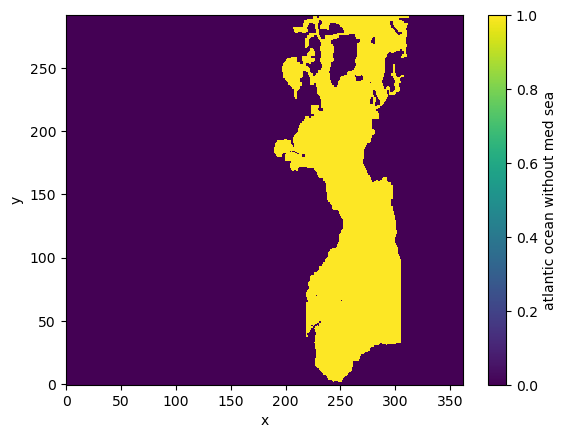

In [ ]:
import xarray as xr

# -----------------------------
# 1. Load the mask
# -----------------------------
mask_file = "/data/users/mde/FREJA/subbasins.nc"
mask_ds = xr.open_dataset(mask_file)

# -----------------------------
# 2. Inspect the dataset
# -----------------------------
print(mask_ds)  # prints dimensions, coordinates, and data variables
print(mask_ds.coords)  # prints coordinate variables

# -----------------------------
# 3. List the variables
# -----------------------------
print("Variables in the mask dataset:", list(mask_ds.data_vars))

# -----------------------------
# 4. View one of the variables (for example, the first one)
# -----------------------------
first_var_name = list(mask_ds.data_vars)[0]
mask_data = mask_ds[first_var_name]
print(mask_data)  # prints the DataArray with values and coordinates

# -----------------------------
# 5. Optional: quick plot to see the mask
# -----------------------------
mask_data.plot()




In [4]:
import xarray as xr
import numpy as np
# 1. Load the mask (auto-detect variable and align to thetao grid)
# -----------------------------
mask_file = "/data/users/mde/FREJA/subbasins.nc"
mask_ds = xr.open_dataset(mask_file)

# load thetao to get its grid
thetao_file = "/data/projects/nckf/frekle/CMIP6_data/thetao/thetao_Oyear_EC-Earth3_historical_r1i1p1f1_gn_185001-201412.nc"
thetao = xr.open_dataset(thetao_file)['thetao']

# Auto-detect a mask variable that has lat/lon dims; fall back to the first data var
mask_vars = list(mask_ds.data_vars)
candidates = [v for v in mask_vars if (any(k in mask_ds[v].dims for k in ['latitude','lat','y','j']) and any(k in mask_ds[v].dims for k in ['longitude','lon','x','i']))]
mask_var = candidates[0] if candidates else mask_vars[0]
print("Using mask variable:", mask_var)
mask = mask_ds[mask_var].squeeze()

# -----------------------------
# 2. Align/interpolate mask to the thetao horizontal grid (nearest neighbour)
# -----------------------------
thetao_grid = thetao.isel(time=0).drop_vars([v for v in thetao.coords if v == 'time' or v == 'lev']) if 'time' in thetao.coords else thetao.isel(time=0)
# Ensure mask and thetao_grid have compatible dimensions for interpolation
if 'latitude' in mask.coords and 'longitude' in mask.coords:
    mask_on_grid = mask.interp(latitude=thetao_grid['latitude'], longitude=thetao_grid['longitude'], method='nearest')
elif 'lat' in mask.coords and 'lon' in mask.coords:
    mask_on_grid = mask.interp(lat=thetao_grid['lat'], lon=thetao_grid['lon'], method='nearest')
elif 'nav_lat' in mask_ds.data_vars and 'nav_lon' in mask_ds.data_vars:
    # Use nav_lat and nav_lon from mask_ds for interpolation
    mask_on_grid = mask.interp(
        y=thetao_grid['j'], x=thetao_grid['i'],
        kwargs={"fill_value": None},
        method='nearest'
    )
else:
    raise ValueError("Mask does not have recognizable latitude/longitude coordinates for interpolation.")

# Build a boolean mask (True inside the region). Treat non-zero & finite as inside.
mask_bool = (np.isfinite(mask_on_grid)) & (mask_on_grid != 0)

# save the mask for future reference
# mask_bool.to_netcdf("mask_bool2.nc")

# Print mask info
print(mask_bool)

Using mask variable: atlmsk
<xarray.DataArray 'atlmsk' (j: 292, i: 362)> Size: 106kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(292, 362))
Coordinates:
    y        (j) int32 1kB 1 2 3 4 5 6 7 8 9 ... 285 286 287 288 289 290 291 292
    x        (i) int32 1kB 1 2 3 4 5 6 7 8 9 ... 355 356 357 358 359 360 361 362
  * j        (j) int32 1kB 1 2 3 4 5 6 7 8 9 ... 285 286 287 288 289 290 291 292
  * i        (i) int32 1kB 1 2 3 4 5 6 7 8 9 ... 355 356 357 358 359 360 361 362


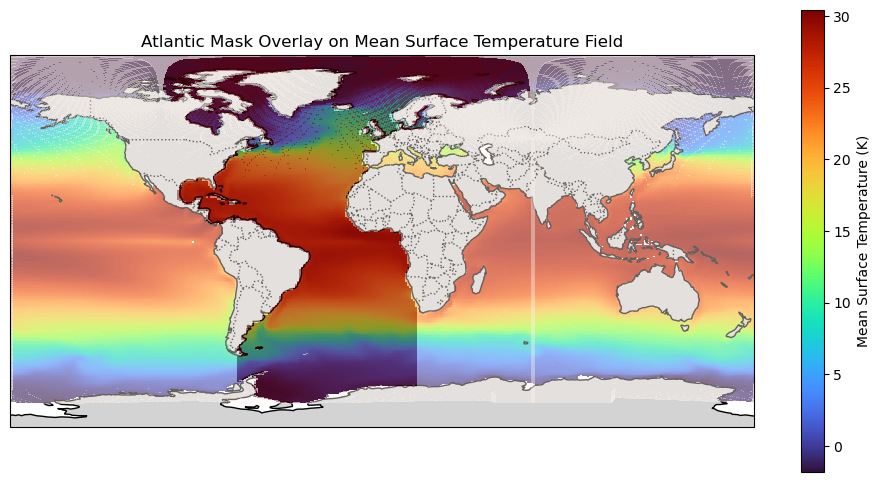

In [11]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------------
# 1. Load datasets
# -----------------------------
thetao_file = "/data/projects/nckf/frekle/CMIP6_data/thetao/thetao_Oyear_EC-Earth3_historical_r1i1p1f1_gn_185001-201412.nc"
mask_file = "/data/users/frekle/mask_bool2.nc"

thetao_ds = xr.open_dataset(thetao_file)
mask_ds = xr.open_dataset(mask_file)

# Extract top layer mean for background
thetao_surf_mean = thetao_ds["thetao"].isel(lev=0).mean(dim="time")

# Extract mask
mask = mask_ds["atlmsk"]

# Get latitude and longitude from thetao dataset
lat = thetao_ds['latitude']
lon = thetao_ds['longitude']

# -----------------------------
# 2. Plot
# -----------------------------
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.BORDERS, linestyle=':', zorder=0)
ax.set_global()

# Plot thetao mean as background
pcm = ax.pcolormesh(
    lon, lat, thetao_surf_mean,
    transform=ccrs.PlateCarree(),
    cmap='turbo',
    shading='auto'
)
fig.colorbar(pcm, ax=ax, orientation='vertical', label='Mean Surface Temperature (K)')

# Plot mask overlay using thetao lat/lon
ax.pcolormesh(
    lon,
    lat,
    mask,
    transform=ccrs.PlateCarree(),
    cmap='Reds',
    alpha=0.4,
    zorder=2
)

plt.title("Atlantic Mask Overlay on Mean Surface Temperature Field")
plt.show()


In [12]:
import xarray as xr

# --- File paths ---
thetao_path = "/data/projects/nckf/frekle/CMIP6_data/thetao/thetao_Oyear_EC-Earth3_historical_r1i1p1f1_gn_185001-201412.nc"
so_path = "/data/projects/nckf/frekle/CMIP6_data/so/so_Oyear_EC-Earth3_historical_r1i1p1f1_gn_185001-201412.nc"
mask_path = "/data/users/frekle/mask_bool2.nc"

# --- Output paths ---
thetao_masked_out = "/data/projects/nckf/frekle/CMIP6_data/thetao/thetao_masked.nc"
so_masked_out = "/data/projects/nckf/frekle/CMIP6_data/so/so_masked.nc"

# --- Load datasets ---
ds_thetao = xr.open_dataset(thetao_path)
ds_so = xr.open_dataset(so_path)
ds_mask = xr.open_dataset(mask_path)

# --- Load mask variable (assume it's named 'atlmsk') ---
mask = ds_mask["atlmsk"]

# --- Ensure mask is boolean ---
mask = mask.astype(bool)
 
# --- Apply mask to all depth levels (3D mask) ---
thetao = ds_thetao["thetao"]
so = ds_so["so"]

# Expand mask along the vertical (lev) dimension
mask_3d = mask.broadcast_like(thetao)

# Apply mask
thetao_masked = thetao.where(mask_3d)
so_masked = so.where(mask_3d)

# --- Save masked data ---
thetao_masked.to_dataset(name="thetao").to_netcdf(thetao_masked_out)
so_masked.to_dataset(name="so").to_netcdf(so_masked_out)

print("✅ 3D masked files saved successfully:")
print(f"- {thetao_masked_out}")
print(f"- {so_masked_out}")


✅ 3D masked files saved successfully:
- /data/projects/nckf/frekle/CMIP6_data/thetao/thetao_masked.nc
- /data/projects/nckf/frekle/CMIP6_data/so/so_masked.nc


In [9]:
# Mask for mlotst and msfytz

# --- File paths ---
mlotst_path = "/data/projects/nckf/frekle/CMIP6_data/mlotst/mlotst_Oyear_EC-Earth3_historical_r1i1p1f1_gn_185001-201412.nc"
msftyz_path = "/data/projects/nckf/frekle/CMIP6_data/msftyz/msftyz_Oyear_EC-Earth3_historical_r1i1p1f1_gn_185001-201412.nc"
mask_path = "/data/users/frekle/mask_bool2.nc"

# --- Output paths ---
mlotst_masked_out = "/data/projects/nckf/frekle/CMIP6_data/mlotst/mlotst_masked.nc"
msftyz_masked_out = "/data/projects/nckf/frekle/CMIP6_data/msftyz/msftyz_masked.nc"

# --- Load datasets ---
ds_mlotst = xr.open_dataset(mlotst_path)
ds_msftyz = xr.open_dataset(msftyz_path)
ds_mask = xr.open_dataset(mask_path)

# --- Load mask variable (assume it's named 'atlmsk') ---
mask = ds_mask["atlmsk"]

# --- Ensure mask is boolean ---
mask = mask.astype(bool)
 
# --- Apply mask to all depth levels (3D mask) ---
mlotst = ds_mlotst["mlotst"]
msftyz = ds_msftyz["msftyz"]

# Expand mask along the vertical (lev) dimension
mask_3d_mlotst = mask.broadcast_like(mlotst)
mask_3d_msftyz = mask.broadcast_like(msftyz)

# Apply mask
mlotst_masked = mlotst.where(mask_3d_mlotst)
#msftyz_masked = msftyz.where(mask_3d_msftyz)

# --- Save masked data ---
mlotst_masked.to_dataset(name="mlotst").to_netcdf(mlotst_masked_out)
# msftyz_masked.to_dataset(name="msftyz").to_netcdf(msftyz_masked_out)

print("✅ 3D masked files saved successfully:")
print(f"- {mlotst_masked_out}")
# print(f"- {msftyz_masked_out}")


✅ 3D masked files saved successfully:
- /data/projects/nckf/frekle/CMIP6_data/mlotst/mlotst_masked.nc


### Loop through all members

🧪 Testing mask overlay on: r10i1p1f1
✅ Mask dims: ('j', 'i'), dtype: bool

✅ Masking applied in memory.
Original dims: (165, 75, 292, 362)
Masked dims:   (165, 75, 292, 362)


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:512: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:512: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  return super().draw(renderer=renderer, **kwargs)


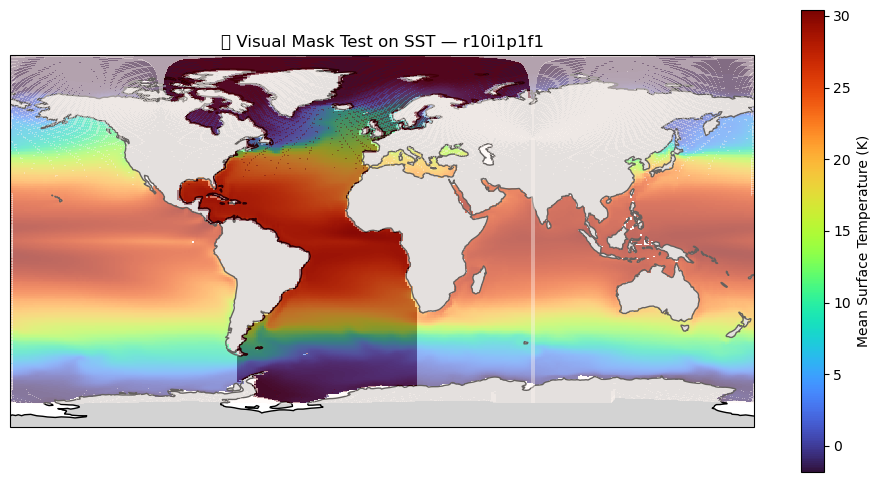


🎉 Test completed. No files were saved — this was only a visual check.


In [6]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from glob import glob

# --- Test setup ---
src_base = "/dmidata/projects/nckf/cmip6/historical/EC-Earth3"
mask_path = "/data/users/frekle/mask_bool2.nc"

member_path = sorted(glob(f"{src_base}/r*i1p1f1"))[0]  # just first member
member = member_path.split("/")[-1]
print(f"🧪 Testing mask overlay on: {member}")

# --- Load mask ---
mask = xr.open_dataset(mask_path)["atlmsk"].astype(bool).reset_coords(drop=True)
print(f"✅ Mask dims: {mask.dims}, dtype: {mask.dtype}")

# --- Load thetao (SST) for plotting ---
thetao_src = glob(f"{member_path}/Oyear/thetao/thetao_*.nc")[0]
ds_thetao = xr.open_dataset(thetao_src)  # no chunks = fast for plotting
thetao_surf_mean = ds_thetao["thetao"].isel(lev=0).mean(dim="time")

# Get lat/lon for map
lat = ds_thetao["latitude"]
lon = ds_thetao["longitude"]

# --- Apply mask (not saving, just show result) ---
thetao_masked = ds_thetao["thetao"].where(mask)

print("\n✅ Masking applied in memory.")
print(f"Original dims: {ds_thetao['thetao'].shape}")
print(f"Masked dims:   {thetao_masked.shape}")

# --- PLOT ---
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.set_global()

# Background SST
pcm = ax.pcolormesh(
    lon, lat, thetao_surf_mean,
    transform=ccrs.PlateCarree(),
    cmap="turbo",
    shading="auto"
)
fig.colorbar(pcm, ax=ax, orientation='vertical', label='Mean Surface Temperature (K)')

# Mask overlay
ax.pcolormesh(
    lon,
    lat,
    mask,
    transform=ccrs.PlateCarree(),
    cmap='Reds',
    alpha=0.4,
    zorder=2
)

plt.title(f"✅ Visual Mask Test on SST — {member}")
plt.show()

print("\n🎉 Test completed. No files were saved — this was only a visual check.")



In [6]:
import os
from glob import glob
import xarray as xr

# ------------ Paths ------------
src_base = "/data/projects/nckf/frekle/CMIP6_data/CESM2/thetao/"
dst_base = "/data/projects/nckf/frekle/CMIP6_data"
mask_path ="/data/users/frekle/mask_bool_EC-Earth3.nc"  # dims: (j, i), var: atlmsk

# Ensure output folders exist
os.makedirs(f"{dst_base}/thetao", exist_ok=True)
os.makedirs(f"{dst_base}/so", exist_ok=True)

# ------------ Load mask once ------------
ds_mask = xr.open_dataset(mask_path)
mask = ds_mask["atlmsk"].astype(bool)  # (j, i)

# ------------ Find ensemble members ------------
members = sorted(glob(f"{src_base}/r*i1p1f1"))

if not members:
    raise RuntimeError("No ensemble member folders found under "
                       f"{src_base}/r*i1p1f1")

for member_path in members:
    member = os.path.basename(member_path)  # e.g., r1i1p1f1
    print(f"\n🔄 Processing {member} ...")

    # Locate input files (one per var)
    thetao_src_list = glob(f"{member_path}/Oyear/thetao/thetao_*.nc")
    so_src_list     = glob(f"{member_path}/Oyear/so/so_*.nc")

    if not thetao_src_list or not so_src_list:
        print(f"⚠️  Missing thetao/so input for {member} — skipping.")
        continue

    thetao_src = thetao_src_list[0]
    so_src     = so_src_list[0]

    # Open datasets (no compression/chunking; same approach as your single-member script)
    ds_thetao = xr.open_dataset(thetao_src)
    ds_so     = xr.open_dataset(so_src)

    thetao = ds_thetao["thetao"]  # (time, lev, j, i)
    so     = ds_so["so"]          # (time, lev, j, i)

    # --- 3D broadcast of mask (exactly as in your working example) ---
    mask_3d = mask.broadcast_like(thetao)  # expands to (time, lev, j, i)

    # Apply mask
    thetao_masked = thetao.where(mask_3d)
    so_masked     = so.where(mask_3d)

    # Output paths (overwrite if exists)
    thetao_out = f"{dst_base}/thetao/masked/thetao_masked_{member}.nc"
    so_out     = f"{dst_base}/so/masked/so_masked_{member}.nc"

    # Save (no compression)
    thetao_masked.to_dataset(name="thetao").to_netcdf(thetao_out)
    so_masked.to_dataset(name="so").to_netcdf(so_out)

    print(f"✅ Saved: {thetao_out}")
    print(f"✅ Saved: {so_out}")

print("\n🎉 All ensemble members processed (SST + SSS, 3D mask applied, no compression).")



RuntimeError: No ensemble member folders found under /data/projects/nckf/frekle/CMIP6_data/CESM2/thetao//r*i1p1f1

KeyError: 'lon'

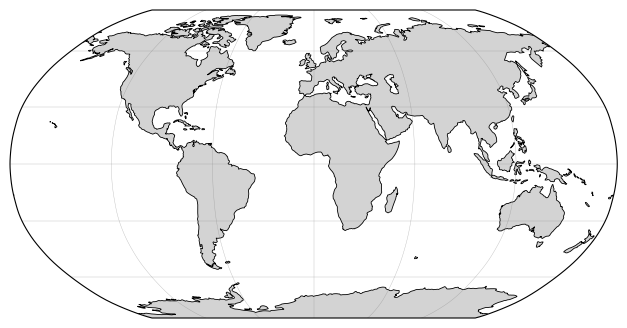

In [6]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ==========================================================
# 1. Load EN4 data
# ==========================================================
en4_file = "/data/projects/nckf/frekle/CMIP6_data/so/EN4_SSS_surface_1900_2014_Atl.nc"
ds = xr.open_dataset(en4_file)

# Select salinity for a given year (surface only)
year = 2000
sss = ds["salinity_masked"].sel(time=str(year), method="nearest")

# ==========================================================
# 2. Plot with Cartopy
# ==========================================================
plt.figure(figsize=(9, 4))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

# Add coastlines and grid
ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

# Plot salinity
im = ax.pcolormesh(
    sss["lon"], sss["lat"], sss,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    shading="auto"
)

# Colorbar and title
plt.colorbar(im, orientation="horizontal", pad=0.05, label="Salinity (psu)")
plt.title(f"EN4 Surface Salinity ({year})", fontsize=12)
plt.tight_layout()
plt.show()


In [16]:
"""
Mask EN4 surface salinity to the Atlantic domain
and save as NetCDF.

Freja Klejnstrup — 2025
"""

import xarray as xr
import numpy as np
import os
from scipy.interpolate import RegularGridInterpolator

# ==========================================================
# 1. Paths
# ==========================================================
en4_file = "/data/projects/nckf/frekle/obs_data/EN4_SSS_surface_1900_2014.nc"
mask_file = "/data/users/frekle/mask_bool2.nc"
model_ref = "/data/projects/nckf/frekle/CMIP6_data/so/so_masked_r1i1p1f1.nc"
out_file  = "/data/projects/nckf/frekle/CMIP6_data/so/EN4_SSS_surface_1900_2014_Atl.nc"

os.makedirs(os.path.dirname(out_file), exist_ok=True)

# ==========================================================
# 2. Load data
# ==========================================================
print("📥 Loading EN4 salinity and Atlantic mask...")
en4 = xr.open_dataset(en4_file)
en4_sss = en4["salinity"].sel(time=slice("1900", "2014"))

mask_ds = xr.open_dataset(mask_file)
ds_ref = xr.open_dataset(model_ref)

# Detect mask variable name
mask_var = [v for v in mask_ds.data_vars if mask_ds[v].dtype == bool or mask_ds[v].dtype == np.int_][0]
mask = mask_ds[mask_var]

print(f"✅ Mask variable detected: {mask_var} | shape = {mask.shape}")

# ==========================================================
# 3. Interpolation function
# ==========================================================
def regrid_to_model(en4_field, model_lat, model_lon):
    """Interpolate EN4 (regular lat/lon) to model (curvilinear lat/lon)."""
    en4_lat = en4_field["lat"].values
    en4_lon = en4_field["lon"].values
    data = en4_field.values

    f_interp = RegularGridInterpolator((en4_lat, en4_lon), data, bounds_error=False, fill_value=np.nan)
    points = np.array([model_lat.values.ravel(), model_lon.values.ravel()]).T
    new_vals = f_interp(points).reshape(model_lat.shape)

    return xr.DataArray(
        new_vals,
        dims=("j", "i"),
        coords={"j": model_lat["j"], "i": model_lon["i"]},
        attrs=en4_field.attrs,
    )

# ==========================================================
# 4. Regrid EN4 to EC-Earth3 grid and apply mask
# ==========================================================
print("⏳ Regridding EN4 to EC-Earth3 grid...")
model_lat = ds_ref["latitude"]
model_lon = ds_ref["longitude"]

# Apply regridding for each time step
masked_list = []
for t in en4_sss.time:
    field_t = en4_sss.sel(time=t)
    regridded = regrid_to_model(field_t, model_lat, model_lon)
    masked_list.append(regridded.where(mask))

masked_en4 = xr.concat(masked_list, dim=en4_sss["time"])
masked_en4.name = "salinity"
masked_en4.attrs["description"] = "EN4 salinity masked to Atlantic domain (EC-Earth3 grid)"

print("✅ EN4 successfully regridded and masked.")

# ==========================================================
# 5. Save new masked EN4 file
# ==========================================================
masked_en4.to_netcdf(out_file)
print(f"💾 Saved masked EN4 dataset to:\n   {out_file}")


📥 Loading EN4 salinity and Atlantic mask...
✅ Mask variable detected: atlmsk | shape = (292, 362)
⏳ Regridding EN4 to EC-Earth3 grid...


KeyboardInterrupt: 

/tmp/ipykernel_523953/2270346142.py:17: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  en4["time"] = xr.cftime_range(start="1900", periods=len(en4.time), freq="M")
/tmp/ipykernel_523953/2270346142.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version. Please use 'ME' instead of 'M'.
  en4["time"] = xr.cftime_range(start="1900", periods=len(en4.time), freq="M")


Grid shape: (1380, 292, 362)
NaN fraction: 0.9339854688564293
Value range: 3.0667191433138097 40.305662063406594


<string>:7: FutureWarning: 'Y' is deprecated and will be removed in a future version. Please use 'YE' instead of 'Y'.


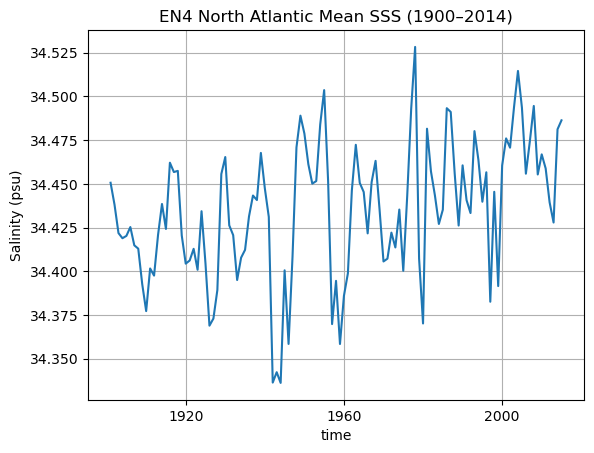

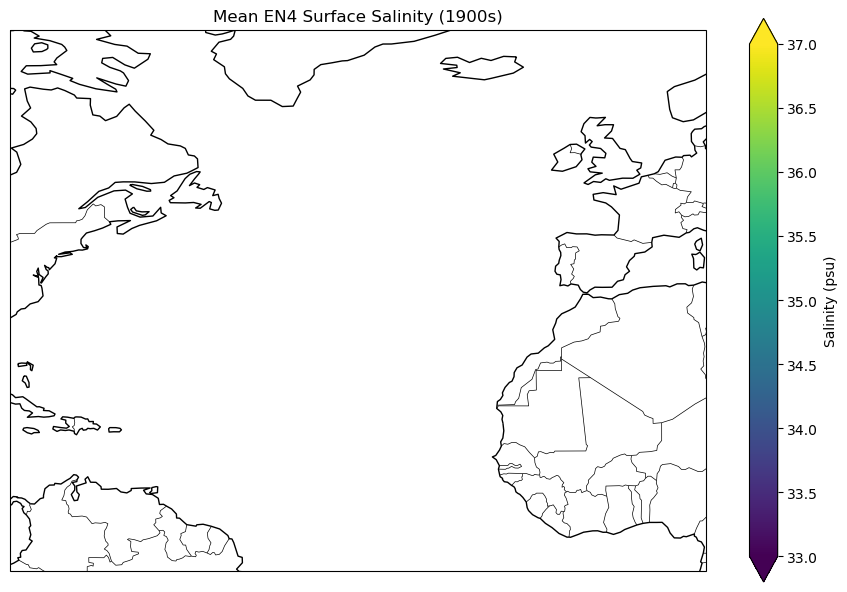

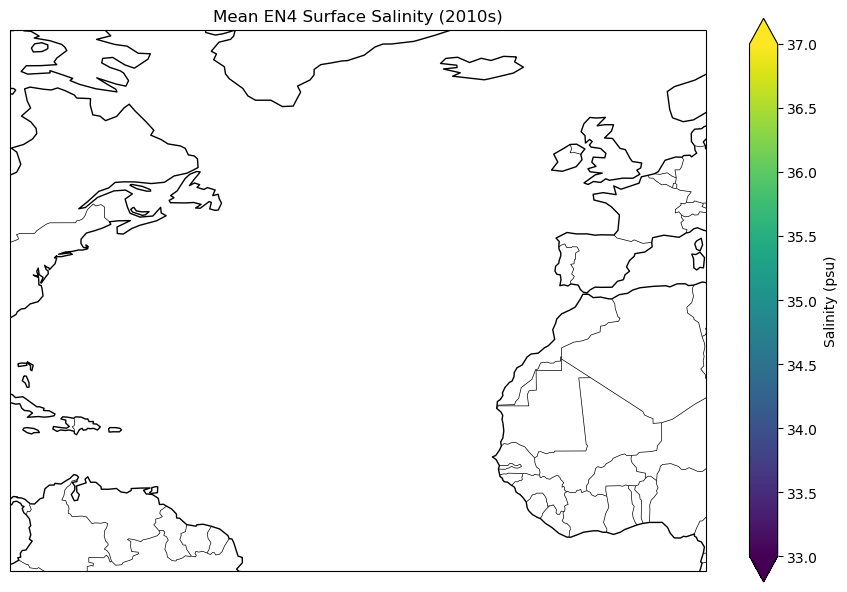

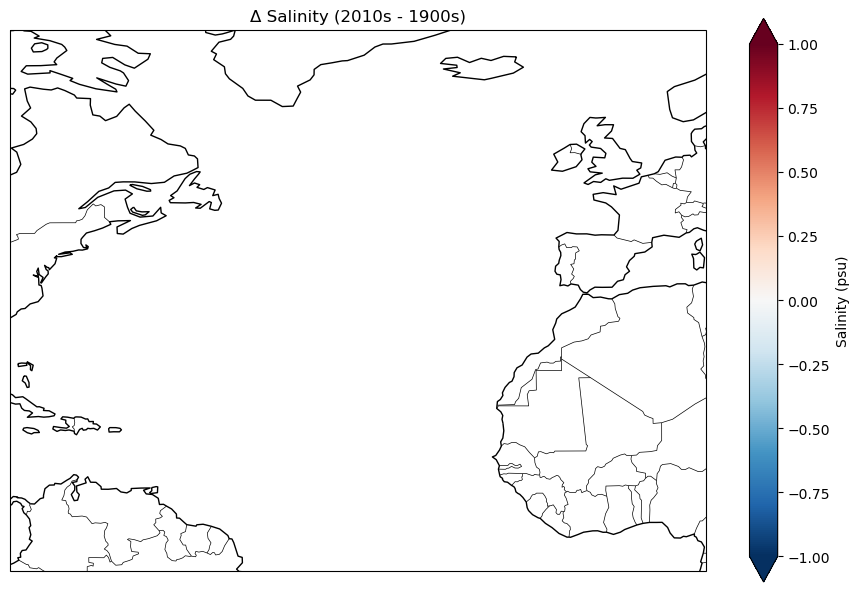

Trend stats: -0.17384355367375817 0.1558589249449358 0.004781609648480566
Valid cells: 6978


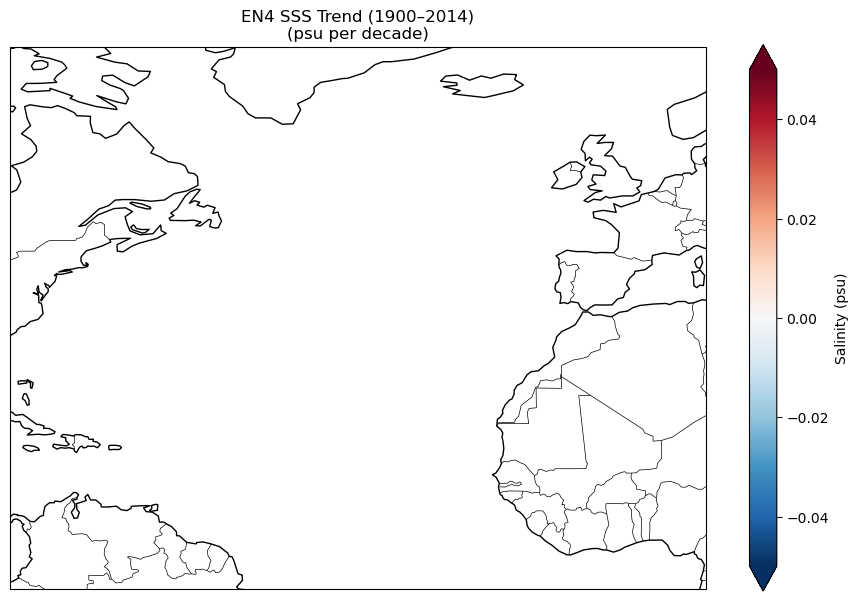

In [23]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------------
# File paths
# -----------------------------
en4_path = "/data/projects/nckf/frekle/CMIP6_data/so/EN4_SSS_surface_1900_2014_Atl.nc"
ref_path = "/data/projects/nckf/frekle/CMIP6_data/so/so_masked_r1i1p1f1.nc"

# -----------------------------
# Load EN4 and attach coordinates
# -----------------------------
en4 = xr.open_dataset(en4_path)
en4["time"] = xr.cftime_range(start="1900", periods=len(en4.time), freq="M")
sss = en4["salinity_masked"]

# Attach lat/lon from model grid as coordinates
ref = xr.open_dataset(ref_path)
lat = ref["latitude"]
lon = ref["longitude"]
sss = sss.assign_coords(latitude=lat, longitude=lon)
ref.close()

# -----------------------------
# Apply mask (latitude only)
# -----------------------------
sss = sss.where((sss.latitude > 0) & (sss.latitude < 70))

# -----------------------------
# Diagnostics
# -----------------------------
print("Grid shape:", sss.shape)
print("NaN fraction:", float(np.isnan(sss).mean()))
print("Value range:", float(sss.min(skipna=True)), float(sss.max(skipna=True)))

# -----------------------------
# Yearly mean and area mean
# -----------------------------
sss_yearly = sss.resample(time="Y").mean()
sss_area_mean = sss_yearly.mean(("j","i"), skipna=True)

plt.figure()
sss_area_mean.plot()
plt.title("EN4 North Atlantic Mean SSS (1900–2014)")
plt.ylabel("Salinity (psu)")
plt.grid(True)
plt.show()

# -----------------------------
# First/last decade mean maps
# -----------------------------
first_decade = sss.sel(time=slice("1900-01-01", "1909-12-31")).mean("time")
last_decade = sss.sel(time=slice("2005-01-01", "2014-12-31")).mean("time")
diff = last_decade - first_decade

def plot_map(data, title, vmin=None, vmax=None, cmap="viridis"):
    plt.figure(figsize=(9,6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    data.plot(ax=ax, transform=ccrs.PlateCarree(),
              cmap=cmap, vmin=vmin, vmax=vmax,
              cbar_kwargs={"label": "Salinity (psu)"})
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_extent([-80, 10, 0, 70], crs=ccrs.PlateCarree())
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_map(first_decade, "Mean EN4 Surface Salinity (1900s)", vmin=33, vmax=37)
plot_map(last_decade, "Mean EN4 Surface Salinity (2010s)", vmin=33, vmax=37)
plot_map(diff, "Δ Salinity (2010s - 1900s)", vmin=-1, vmax=1, cmap="RdBu_r")

# -----------------------------
# Compute linear trend (robust)
# -----------------------------
years = sss_yearly["time"].dt.year.values

def trend_func(y):
    mask = np.isfinite(y)
    if mask.sum() < 10:
        return np.nan
    slope = np.polyfit(years[mask], y[mask], 1)[0] * 10  # per decade
    return slope

trend = xr.apply_ufunc(
    trend_func,
    sss_yearly,
    input_core_dims=[["time"]],
    output_dtypes=[float],
    vectorize=True
)

print("Trend stats:", float(trend.min(skipna=True)),
      float(trend.max(skipna=True)),
      float(trend.mean(skipna=True)))
print("Valid cells:", int(np.isfinite(trend).sum()))

# -----------------------------
# Plot trend map
# -----------------------------
if np.isfinite(trend).sum() > 0:
    plot_map(trend, "EN4 SSS Trend (1900–2014)\n(psu per decade)",
             vmin=-0.05, vmax=0.05, cmap="RdBu_r")
else:
    print("⚠️ No valid trend values — likely over-masking or NaN grid.")






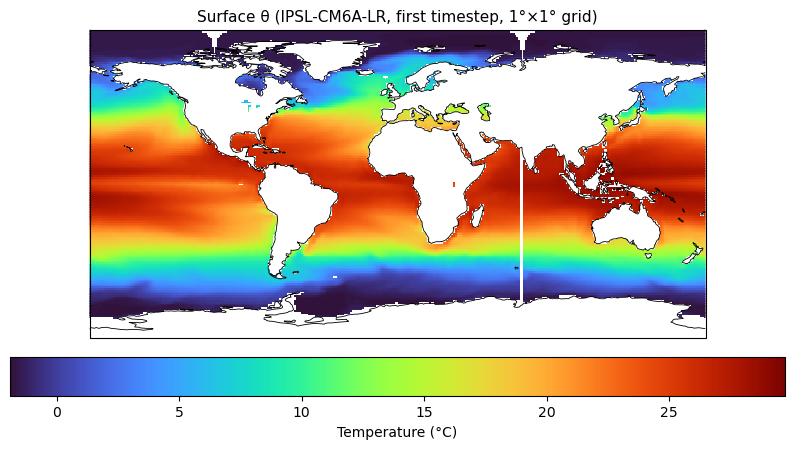

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# File path
f = "/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao_3D_regrid_IPSL-CM6A-LR_r1i1p1f1.nc"

# Open the dataset
ds = xr.open_dataset(f)
da = ds["thetao"]

# Pick the first time step and surface level (0 m)
surface = da.isel(time=0, olevel=0)

# Plot
fig = plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.PlateCarree())
pc = ax.pcolormesh(surface.lon, surface.lat, surface, transform=ccrs.PlateCarree(), cmap="turbo")
ax.coastlines(linewidth=0.6)
ax.set_title("Surface θ (IPSL-CM6A-LR, first timestep, 1°×1° grid)", fontsize=11)
cb = plt.colorbar(pc, ax=ax, orientation="horizontal", pad=0.05, label="Temperature (°C)")
plt.show()


In [5]:
import xarray as xr
import numpy as np

datafile = "/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao_3D_regrid_IPSL-CM6A-LR_r1i1p1f1.nc"
maskfile = "/data/users/frekle/mask_bool_IPSL_1deg.nc"

# Open both
ds = xr.open_dataset(datafile)
da = ds["thetao"].isel(time=0, olevel=0)
mask = xr.open_dataset(maskfile)
mask_var = list(mask.data_vars)[0]  # automatically pick first variable
m = mask[mask_var]

# Print coordinate info
print("\n--- DATA grid ---")
print("lat:", da.lat.values[:5], "...", da.lat.values[-5:])
print("lon:", da.lon.values[:5], "...", da.lon.values[-5:])

print("\n--- MASK grid ---")
print("lat:", m.lat.values[:5], "...", m.lat.values[-5:])
print("lon:", m.lon.values[:5], "...", m.lon.values[-5:])

print("\nLongitude range difference:",
      da.lon.values[0], "→", da.lon.values[-1],
      "vs", m.lon.values[0], "→", m.lon.values[-1])
print("Longitude step:", np.diff(da.lon.values[:2])[0])





--- DATA grid ---
lat: [-89.5 -88.5 -87.5 -86.5 -85.5] ... [85.5 86.5 87.5 88.5 89.5]
lon: [0. 1. 2. 3. 4.] ... [355. 356. 357. 358. 359.]

--- MASK grid ---
lat: [-89.5 -88.5 -87.5 -86.5 -85.5] ... [85.5 86.5 87.5 88.5 89.5]
lon: [0.5 1.5 2.5 3.5 4.5] ... [355.5 356.5 357.5 358.5 359.5]

Longitude range difference: 0.0 → 359.0 vs 0.5 → 359.5
Longitude step: 1.0


In [6]:
import xarray as xr

maskfile = "/data/users/frekle/mask_bool_IPSL_1deg.nc"
m = xr.open_dataset(maskfile)
mask_var = list(m.data_vars)[0]
mask = m[mask_var]

# Shift longitude centers back by 0.5°
mask = mask.assign_coords(lon=(mask.lon - 0.5) % 360)

# Save corrected mask
mask_corrected = mask.sortby("lon")
mask_corrected.to_netcdf("/data/users/frekle/mask_bool_IPSL_1deg_aligned.nc")
print("✅ Saved:", "/data/users/frekle/mask_bool_IPSL_1deg_aligned.nc")


✅ Saved: /data/users/frekle/mask_bool_IPSL_1deg_aligned.nc


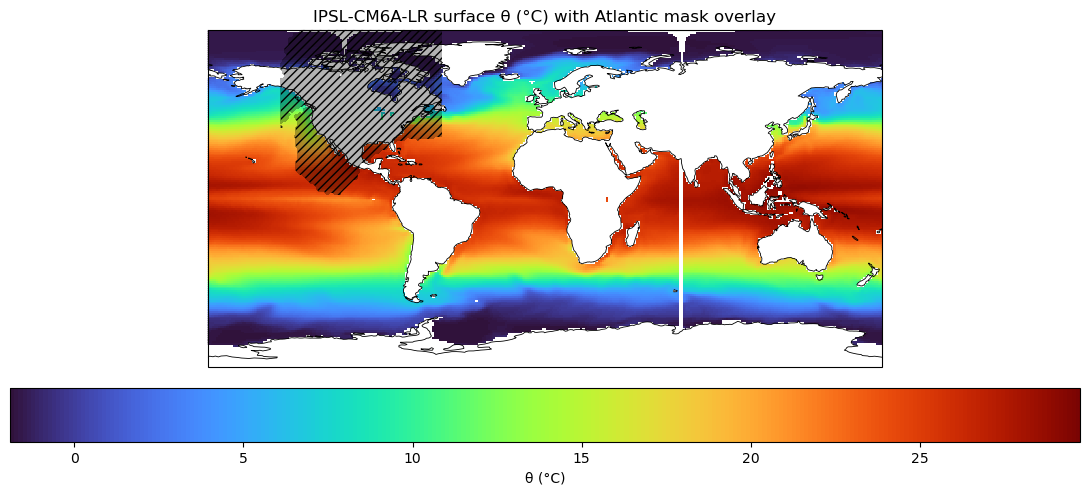

In [18]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# ---------------- FILE PATHS ----------------
datafile = "/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao_3D_regrid_IPSL-CM6A-LR_r1i1p1f1.nc"
maskfile = "/data/users/frekle/mask_bool_EC-Earth3.nc"

# ---------------- LOAD DATA ----------------
ds = xr.open_dataset(datafile)
da = ds["thetao"].isel(time=0, olevel=0)   # first time step, surface

mask = xr.open_dataarray(maskfile)
# If variable name is different (e.g. 'atlmsk'), open_dataset and select:
# mask = xr.open_dataset(maskfile)["atlmsk"]
mask = mask.astype(float)

# ---------------- PLOT ----------------
fig = plt.figure(figsize=(11,5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Base layer: temperature field
pcm = ax.pcolormesh(
    da["lon"], da["lat"], da,
    cmap="turbo", transform=ccrs.PlateCarree()
)
cb = plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.05, label="θ (°C)")
ax.set_title("IPSL-CM6A-LR surface θ (°C) with Atlantic mask overlay")

# Overlay: transparent mask (gray)
mask_plot = mask.where(mask > 0.5)
ax.contourf(
    mask_plot["i"], mask_plot["j"], mask_plot,
    levels=[0.5,1.5], colors="none",
    hatches=["////"], transform=ccrs.PlateCarree(), alpha=0.3
)

ax.coastlines(linewidth=0.6)
plt.tight_layout()
plt.show()


In [20]:
import xarray as xr
import numpy as np

# ---- File paths ----
datafile = "/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao_3D_regrid_IPSL-CM6A-LR_r1i1p1f1.nc"
mask_out = "/data/users/frekle/mask_bool_IPSL_fromdata.nc"

# ---- Load dataset ----
ds = xr.open_dataset(datafile)
da = ds["thetao"]

# ---- Create ocean mask ----
# Where the temperature is finite, define ocean = 1; else 0
mask = xr.where(np.isfinite(da.isel(time=0, olevel=0)), 1, 0).astype(np.int8)

# Keep lat/lon coordinates
mask = mask.rename("atlmsk")
mask.attrs["description"] = "Atlantic/ocean mask derived from IPSL-CM6A-LR thetao grid (1°x1°)"
mask.attrs["note"] = "1 = ocean, 0 = land (based on finite thetao values)"

# ---- Save ----
mask.to_netcdf(mask_out)
print("✅ New mask saved:", mask_out)



✅ New mask saved: /data/users/frekle/mask_bool_IPSL_fromdata.nc


In [1]:
import xarray as xr
import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# ---------------- FILE PATHS ----------------
subbasins = "/data/users/mde/FREJA/subbasins.nc"  # supervisor's mask
ipsl_grid = "/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao_3D_regrid_IPSL-CM6A-LR_r1i1p1f1.nc"
out_mask  = "/data/users/frekle/mask_bool_IPSL.nc"

# ---------------- LOAD SOURCE (tripolar grid) ----------------
ds_sub = xr.open_dataset(subbasins)
atl = ds_sub["atlmsk"].load()
lon_src = (ds_sub["nav_lon"].load() % 360)  # ensure 0–360 range
lat_src = ds_sub["nav_lat"].load()

# Flatten and clean
atl_vals = atl.values.ravel()
lon_vals = lon_src.values.ravel()
lat_vals = lat_src.values.ravel()
good = np.isfinite(atl_vals) & np.isfinite(lon_vals) & np.isfinite(lat_vals)
atl_vals, lon_vals, lat_vals = atl_vals[good], lon_vals[good], lat_vals[good]

# ---------------- LOAD TARGET (IPSL 1°×1° grid) ----------------
ref = xr.open_dataset(ipsl_grid)
lon_t = ref["lon"].values
lat_t = ref["lat"].values
lon_t2, lat_t2 = np.meshgrid(lon_t, lat_t)
lon_t2 = lon_t2 % 360

# ---------------- KD-TREE NEAREST NEIGHBOUR ----------------
def sph2cart(lon_deg, lat_deg):
    lon = np.deg2rad(lon_deg)
    lat = np.deg2rad(lat_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    return np.column_stack((x, y, z))

src_xyz = sph2cart(lon_vals, lat_vals)
tree = cKDTree(src_xyz)

tgt_xyz = sph2cart(lon_t2.ravel(), lat_t2.ravel())
_, idx = tree.query(tgt_xyz, k=1)
atl_on_tgt = atl_vals[idx].reshape(lat_t2.shape)

# Threshold to boolean mask
mask_ipsl = (atl_on_tgt >= 0.5).astype(np.int8)

# ---------------- SAVE MASK ----------------
da_mask = xr.DataArray(
    mask_ipsl,
    dims=("lat", "lon"),
    coords={"lat": ref["lat"], "lon": ref["lon"]},
    name="atlmsk"
)
da_mask.attrs.update({
    "long_name": "Atlantic mask from subbasins remapped to IPSL 1x1 grid",
    "source": subbasins,
    "method": "KD-tree nearest neighbour on sphere",
    "note": "1 = Atlantic Ocean, 0 = elsewhere"
})
da_mask.to_netcdf(out_mask)
print("✅ Saved:", out_mask)




/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


✅ Saved: /data/users/frekle/mask_bool_IPSL.nc


ValueError: For X (361) and Y (181) with flat shading, A should have shape (180, 360, 3) or (180, 360, 4) or (180, 360) or (64800,), not (180,)

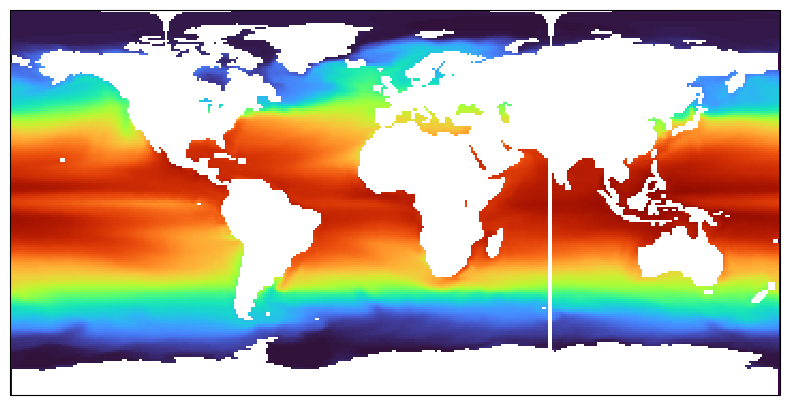

In [6]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# ---------------- FILE PATHS ----------------
datafile = "/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao_3D_regrid_IPSL-CM6A-LR_r1i1p1f1.nc"
maskfile = "/data/projects/nckf/frekle/mask_bool_IPSL.nc"

# ---------------- LOAD ----------------
ds = xr.open_dataset(datafile)
da = ds["thetao"].isel(time=0, olevel=0)  # surface at first timestep
mask = xr.open_dataarray(maskfile).astype(float)

# ---------------- PLOT ----------------
fig = plt.figure(figsize=(11, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Base layer: SST field
pcm = ax.pcolormesh(
    da["lon"], da["lat"], da,
    cmap="turbo",
    transform=ccrs.PlateCarree(),
    shading="nearest"   # ← THIS FIXES THE ERROR
)

plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.05, label="θ (°C)")

# Overlay: transparent Atlantic mask with hatching
mask_plot = mask.where(mask > 0.5)
ax.contourf(
    mask_plot["lon"], mask_plot["lat"], mask_plot,
    levels=[0.5, 1.5],
    colors="none",  # transparent base
    hatches=["////"],  # diagonal stripes
    transform=ccrs.PlateCarree(),
    alpha=0.3
)

ax.coastlines(linewidth=0.6)
ax.set_title("IPSL-CM6A-LR surface θ (°C) with Atlantic mask overlay")
plt.tight_layout()
plt.show()


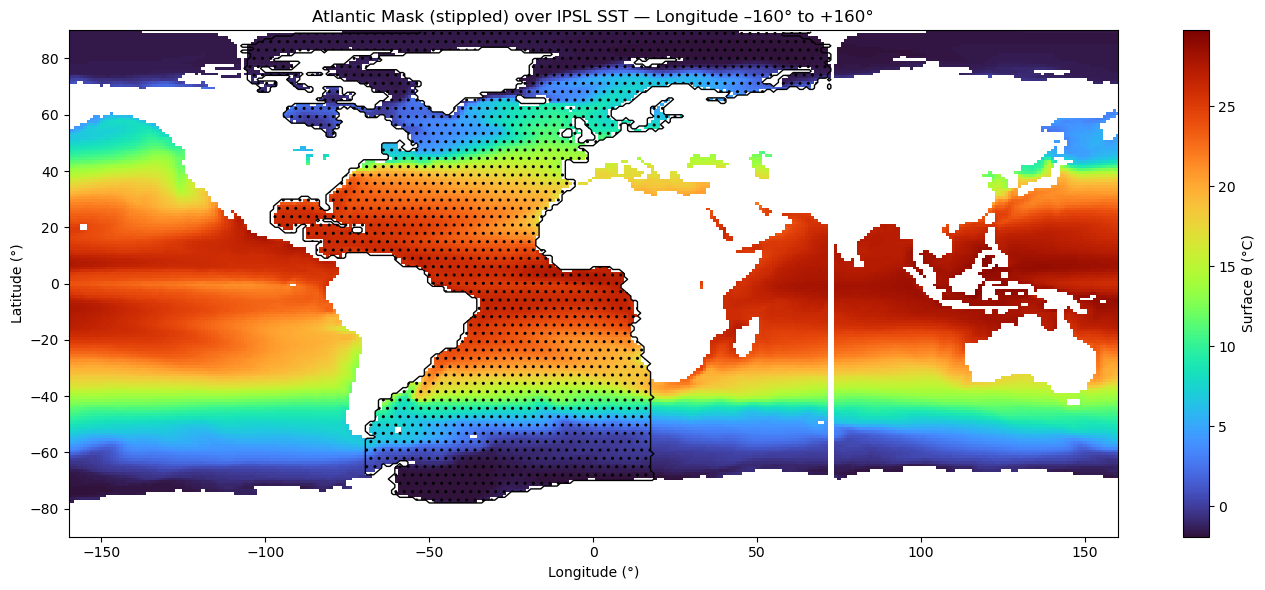

In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# ---------------- FILE PATHS ----------------
datafile = "/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao_3D_regrid_IPSL-CM6A-LR_r1i1p1f1.nc"
maskfile = "/data/users/frekle/mask_bool_IPSL.nc"

# ---------------- LOAD ----------------
ds = xr.open_dataset(datafile)
da = ds["thetao"].isel(time=0, olevel=0)   # shape (180, 360)
mask = xr.open_dataarray(maskfile).astype(float)

# ---------------- CONVERT LON TO -180...180 ----------------
lon = da.lon.values        # 0..359
lon_shifted = ((lon + 180) % 360) - 180   # now -180..179

# Roll data so that lon order matches shifted values
# (because the modulo shifts the coordinate values but not the data)
order = np.argsort(lon_shifted)
lon_sorted = lon_shifted[order]

da_sorted = da.values[:, order]
mask_sorted = mask.values[:, order]

# 2D meshgrid
lon2, lat2 = np.meshgrid(lon_sorted, da.lat.values)

# ---------------- PLOT ----------------
plt.figure(figsize=(14, 6))

# SST background
plt.pcolormesh(
    lon2, lat2, da_sorted,
    cmap="turbo", shading="nearest"
)
plt.colorbar(label="Surface θ (°C)")

# Mask stippling
plt.contourf(
    lon2, lat2, mask_sorted,
    levels=[0.5, 1.5],
    hatches=[".."],
    colors="none",
    alpha=0.0
)

# Mask boundary
plt.contour(
    lon2, lat2, mask_sorted,
    levels=[0.5],
    colors="black",
    linewidths=1.0
)

# ---------------- SET X-AXIS RANGE ----------------
plt.xlim(-160, 160)

plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")
plt.title("Atlantic Mask (stippled) over IPSL SST — Longitude –160° to +160°")

plt.tight_layout()
plt.show()


In [1]:
import xarray as xr
import numpy as np
import os

def apply_mask(infile, maskfile, outfile, varname):
    print(f"\n🌀 Applying mask to {infile}")
    ds = xr.open_dataset(infile)
    da = ds[varname]

    # --- Load and align mask ---
    mask = xr.open_dataarray(maskfile)
    if mask.dtype != bool:
        mask = mask > 0.5

    # Interpolate if needed (to ensure matching grid)
    if not np.array_equal(mask.lon, da.lon) or not np.array_equal(mask.lat, da.lat):
        print("   🔧 Interpolating mask to match data grid...")
        mask = mask.interp(lat=da.lat, lon=da.lon)

    # Expand mask along depth if necessary
    if "olevel" in da.dims:
        mask3d = mask.broadcast_like(da.isel(time=0))
    else:
        mask3d = mask

    # --- Apply mask ---
    masked = da.where(mask3d)

    # --- Wrap in dataset ---
    masked_ds = masked.to_dataset(name=varname)

    # --- Prepare compression safely ---
    comp = dict(zlib=True, complevel=3, shuffle=True)
    enc = {v: comp for v in masked_ds.data_vars if v in [varname, "time_bnds", "olevel_bnds", "area"]}

    # --- Save file ---
    masked_ds.to_netcdf(outfile, encoding=enc)
    print(f"✅ Saved masked file: {outfile}")

    # --- Quick sanity check ---
    print("   Masked NaN fraction:", float(masked.isnull().mean().values))



In [3]:
regridded_file = "/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/so/so_regrid_r1i1p1f1.nc"
maskfile = "/data/users/frekle/Masks/mask_bool_IPSL.nc"   # ✅ correct mask
out_masked_file = "/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/so/so_masked_r1i1p1f1.nc"

apply_mask(regridded_file, maskfile, out_masked_file, "so")



🌀 Applying mask to /data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/so/so_regrid_r1i1p1f1.nc
✅ Saved masked file: /data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/so/so_masked_r1i1p1f1.nc
   Masked NaN fraction: 0.8520637860082304


In [5]:
import xarray as xr
import numpy as np
import os

# -------------------------------
# CONFIGURATION
# -------------------------------
model = "IPSL-CM6A-LR"  # or "CESM2"
var = "so"   # or "so"
base_dir = f"/data/projects/nckf/frekle/CMIP6_data/{model}/{var}"
maskfile = "/data/users/frekle/Masks/mask_bool_IPSL.nc"  # ✅ your working mask

# Load mask once
mask = xr.open_dataset(maskfile)["atlmsk"]
mask = (mask > 0.5)
print(f"✅ Loaded mask: {mask.shape}")

# -------------------------------
# FUNCTION
# -------------------------------
def apply_mask(infile, mask, outfile, varname):
    """Apply Atlantic mask and save cleaned dataset."""
    try:
        ds = xr.open_dataset(infile)
        if varname not in ds:
            print(f"⚠️ Variable {varname} not found in {infile}")
            return

        da = ds[varname]
        masked = da.where(mask)
        masked_ds = masked.to_dataset(name=varname)

        # Copy metadata
        masked_ds.attrs.update(ds.attrs)
        masked_ds[varname].attrs.update(da.attrs)

        # Save safely
        masked_ds.to_netcdf(outfile)
        print(f"✅ Masked & saved: {os.path.basename(outfile)}")

    except PermissionError:
        print(f"⛔ Skipping {os.path.basename(outfile)} — no write permission.")
    except Exception as e:
        print(f"❌ Error with {os.path.basename(outfile)}: {e}")

# -------------------------------
# LOOP OVER MEMBERS
# -------------------------------
files = sorted([
    f for f in os.listdir(base_dir)
    if f.startswith(f"{var}_regrid_r") and f.endswith(".nc")
])

print(f"\n🔍 Found {len(files)} regridded files:")
for f in files:
    print("  ", f)

for f in files:
    infile = os.path.join(base_dir, f)
    member = f.split("_regrid_")[-1].replace(".nc", "")
    outfile = os.path.join(base_dir, f"{var}_masked_{member}.nc")

    # Check write permission before attempting to overwrite
    if os.path.exists(outfile) and not os.access(outfile, os.W_OK):
        print(f"⛔ Skipping (no permission): {outfile}")
        continue

    apply_mask(infile, mask, outfile, var)

print("\n🎯 Done! All accessible files were masked successfully.")




✅ Loaded mask: (180, 360)

🔍 Found 26 regridded files:
   so_regrid_r10i1p1f1.nc
   so_regrid_r11i1p1f1.nc
   so_regrid_r12i1p1f1.nc
   so_regrid_r13i1p1f1.nc
   so_regrid_r14i1p1f1.nc
   so_regrid_r15i1p1f1.nc
   so_regrid_r16i1p1f1.nc
   so_regrid_r17i1p1f1.nc
   so_regrid_r18i1p1f1.nc
   so_regrid_r19i1p1f1.nc
   so_regrid_r1i1p1f1.nc
   so_regrid_r20i1p1f1.nc
   so_regrid_r21i1p1f1.nc
   so_regrid_r22i1p1f1.nc
   so_regrid_r23i1p1f1.nc
   so_regrid_r24i1p1f1.nc
   so_regrid_r25i1p1f1.nc
   so_regrid_r26i1p1f1.nc
   so_regrid_r2i1p1f1.nc
   so_regrid_r3i1p1f1.nc
   so_regrid_r4i1p1f1.nc
   so_regrid_r5i1p1f1.nc
   so_regrid_r6i1p1f1.nc
   so_regrid_r7i1p1f1.nc
   so_regrid_r8i1p1f1.nc
   so_regrid_r9i1p1f1.nc
✅ Masked & saved: so_masked_r10i1p1f1.nc
✅ Masked & saved: so_masked_r11i1p1f1.nc
✅ Masked & saved: so_masked_r12i1p1f1.nc
✅ Masked & saved: so_masked_r13i1p1f1.nc
✅ Masked & saved: so_masked_r14i1p1f1.nc
✅ Masked & saved: so_masked_r15i1p1f1.nc
✅ Masked & saved: so_masked_r16i

In [3]:
import xarray as xr

# ---------------- Paths ----------------
cesm_file = "/data/projects/nckf/frekle/CMIP6_data/CESM2/thetao/thetao_Oyear_CESM2_historical_r1i1p1f1_gn_185001-201412.nc"
mask_file = "/data/users/mde/FREJA/subbasins.nc"

# ---------------- Load datasets ----------------
print("📂 Opening CESM file...")
ds_cesm = xr.open_dataset(cesm_file)

print("\n📂 Opening mask file...")
ds_mask = xr.open_dataset(mask_file)

# ---------------- Extract key variables ----------------
da = ds_cesm["thetao"]         # CESM variable (time, lev, nlat, nlon)
cesm_lat = ds_cesm["lat"]      # 2D (nlat, nlon)
cesm_lon = ds_cesm["lon"]      # 2D (nlat, nlon)

mask_raw = ds_mask["atlmsk"]   # 2D (y, x)
mask_lat = ds_mask["nav_lat"]  # 2D (y, x)
mask_lon = ds_mask["nav_lon"]  # 2D (y, x)

print("\n✔️ Loaded CESM + mask correctly.")

# ---------------- Debug info ----------------

print("======================================")
print("🔍 DEBUG GRID COMPARISON")
print("======================================")

print("\n📌 CESM2 thetao:")
print("thetao shape:     ", da.shape)       # (time, lev, nlat, nlon)
print("CESM lat shape:   ", cesm_lat.shape)
print("CESM lon shape:   ", cesm_lon.shape)
print("CESM lat min/max: ", float(cesm_lat.min()), float(cesm_lat.max()))
print("CESM lon min/max: ", float(cesm_lon.min()), float(cesm_lon.max()))

print("\n📌 Mask file information:")
print("mask_raw shape:", mask_raw.shape)    # (y, x)
print("nav_lat shape: ", mask_lat.shape)
print("nav_lon shape: ", mask_lon.shape)
print("mask lat min/max:", float(mask_lat.min()), float(mask_lat.max()))
print("mask lon min/max:", float(mask_lon.min()), float(mask_lon.max()))

print("\n📌 Unique longitude conventions:")
print("Mask lon < 0?    ", bool((mask_lon < 0).any()))
print("CESM lon < 0?    ", bool((cesm_lon < 0).any()))
print("Mask lon > 180?  ", bool((mask_lon > 180).any()))
print("CESM lon > 180?  ", bool((cesm_lon > 180).any()))

print("\n📌 Monotonicity check:")
print("Is mask_lat monotonic?   ", mask_lat.isnull().all() if mask_lat.ndim == 1 else "2D grid")
print("Is mask_lon monotonic?   ", mask_lon.isnull().all() if mask_lon.ndim == 1 else "2D grid")
print("Is CESM lat monotonic?   ", "2D grid")
print("Is CESM lon monotonic?   ", "2D grid")

print("\n======================================")
print("➡️  Debug info printed. Send this output to me.")
print("======================================")


📂 Opening CESM file...

📂 Opening mask file...

✔️ Loaded CESM + mask correctly.
🔍 DEBUG GRID COMPARISON

📌 CESM2 thetao:
thetao shape:      (165, 60, 384, 320)
CESM lat shape:    (384, 320)
CESM lon shape:    (384, 320)
CESM lat min/max:  -79.2205226074621 89.70640964187461
CESM lon min/max:  0.014731101635748343 359.99602043021787

📌 Mask file information:
mask_raw shape: (292, 362)
nav_lat shape:  (292, 362)
nav_lon shape:  (292, 362)
mask lat min/max: -78.57994842529297 89.74176788330078
mask lon min/max: -179.9965362548828 179.9903106689453

📌 Unique longitude conventions:
Mask lon < 0?     True
CESM lon < 0?     False
Mask lon > 180?   False
CESM lon > 180?   True

📌 Monotonicity check:
Is mask_lat monotonic?    2D grid
Is mask_lon monotonic?    2D grid
Is CESM lat monotonic?    2D grid
Is CESM lon monotonic?    2D grid

➡️  Debug info printed. Send this output to me.


In [4]:
import xarray as xr
import numpy as np
from scipy.spatial import cKDTree
import os

# ---------------- Paths ----------------
cesm_file = "/data/projects/nckf/frekle/CMIP6_data/CESM2/thetao/thetao_Oyear_CESM2_historical_r1i1p1f1_gn_185001-201412.nc"
mask_file = "/data/users/mde/FREJA/subbasins.nc"
out_mask_file = "/data/users/frekle/mask_bool_CESM.nc"

os.makedirs("/data/users/frekle", exist_ok=True)

# ---------------- Load datasets ----------------
ds_cesm = xr.open_dataset(cesm_file)
ds_mask = xr.open_dataset(mask_file)

thetao = ds_cesm["thetao"]
cesm_lat = ds_cesm["lat"]   # (nlat, nlon)
cesm_lon = ds_cesm["lon"]   # (nlat, nlon)

mask_raw = ds_mask["atlmsk"]      # (y, x), 0/1-ish
mask_lat = ds_mask["nav_lat"]     # (y, x)
mask_lon = ds_mask["nav_lon"]     # (y, x)

print("CESM thetao shape:", thetao.shape)
print("CESM lat/lon shape:", cesm_lat.shape, cesm_lon.shape)
print("Mask shape:", mask_raw.shape)

# ---------------- Prepare mask ----------------
# Make it boolean first (Atlantic-only)
mask_bool = mask_raw > 0.5

# Fix mask longitudes from [-180, 180] -> [0, 360]
mask_lon_360 = xr.where(mask_lon < 0, mask_lon + 360, mask_lon)

# ---------------- Build KDTree on mask grid ----------------
print("Building KDTree on mask grid...")
points_mask = np.column_stack([
    mask_lat.values.ravel(),      # lat
    mask_lon_360.values.ravel()   # lon (0–360)
])

tree = cKDTree(points_mask)

# ---------------- Query KDTree for each CESM grid point ----------------
print("Querying nearest neighbours for CESM grid...")
points_cesm = np.column_stack([
    cesm_lat.values.ravel(),
    cesm_lon.values.ravel()
])

dist, idx = tree.query(points_cesm)

mask_flat = mask_bool.values.ravel()
mask_on_cesm_flat = mask_flat[idx]

mask_on_cesm = xr.DataArray(
    mask_on_cesm_flat.reshape(cesm_lat.shape),
    coords=cesm_lat.coords,
    dims=cesm_lat.dims,
    name="atlmsk"
)

print("Mask on CESM grid shape:", mask_on_cesm.shape)

# ---------------- Save remapped mask ----------------
mask_on_cesm.to_dataset(name="atlmsk").to_netcdf(out_mask_file)
print(f"✅ Saved regridded mask to: {out_mask_file}")


CESM thetao shape: (165, 60, 384, 320)
CESM lat/lon shape: (384, 320) (384, 320)
Mask shape: (292, 362)
Building KDTree on mask grid...
Querying nearest neighbours for CESM grid...
Mask on CESM grid shape: (384, 320)
✅ Saved regridded mask to: /data/users/frekle/mask_bool_CESM.nc


In [6]:
import xarray as xr
from glob import glob
import os

# ---------------- Paths ----------------
src_dir = "/data/projects/nckf/frekle/CMIP6_data/CESM2/so"
mask_on_cesm_file = "/data/users/frekle/Masks/mask_bool_CESM.nc"
out_dir = "/data/projects/nckf/frekle/CMIP6_data/CESM2/so/masked"

os.makedirs(out_dir, exist_ok=True)

# ---------------- Load mask on CESM grid ----------------
ds_mask_cesm = xr.open_dataset(mask_on_cesm_file)
mask_on_cesm = ds_mask_cesm["atlmsk"]  # (nlat, nlon), boolean-ish

# ---------------- Find all CESM thetao members ----------------
files = sorted(glob(f"{src_dir}/so_Oyear_CESM2_historical_r*i1p1f1_gn_1850-2014.nc"))

print(f"Found {len(files)} so members:")
for f in files:
    print("  ", os.path.basename(f))

# ---------------- Loop members ----------------
for f in files:
    fname = os.path.basename(f)
    member = fname.split("_")[4]  # r1i1p1f1, r2i1p1f1, ...

    print(f"\n🔄 Masking {member} ...")

    ds = xr.open_dataset(f)
    so = ds["so"]  # (time, lev, nlat, nlon)

    # Broadcast mask to 4D
    mask_4d = mask_on_cesm.broadcast_like(so)

    so_masked = so.where(mask_4d)

    out_file = f"{out_dir}/so_masked_{member}.nc"
    so_masked.to_dataset(name="so").to_netcdf(out_file)

    print(f"✅ Saved: {out_file}")

print("\n🎉 All CESM so members masked with the supervisor mask.")

Found 11 so members:
   so_Oyear_CESM2_historical_r10i1p1f1_gn_1850-2014.nc
   so_Oyear_CESM2_historical_r11i1p1f1_gn_1850-2014.nc
   so_Oyear_CESM2_historical_r1i1p1f1_gn_1850-2014.nc
   so_Oyear_CESM2_historical_r2i1p1f1_gn_1850-2014.nc
   so_Oyear_CESM2_historical_r3i1p1f1_gn_1850-2014.nc
   so_Oyear_CESM2_historical_r4i1p1f1_gn_1850-2014.nc
   so_Oyear_CESM2_historical_r5i1p1f1_gn_1850-2014.nc
   so_Oyear_CESM2_historical_r6i1p1f1_gn_1850-2014.nc
   so_Oyear_CESM2_historical_r7i1p1f1_gn_1850-2014.nc
   so_Oyear_CESM2_historical_r8i1p1f1_gn_1850-2014.nc
   so_Oyear_CESM2_historical_r9i1p1f1_gn_1850-2014.nc

🔄 Masking r10i1p1f1 ...
✅ Saved: /data/projects/nckf/frekle/CMIP6_data/CESM2/so/masked/so_masked_r10i1p1f1.nc

🔄 Masking r11i1p1f1 ...
✅ Saved: /data/projects/nckf/frekle/CMIP6_data/CESM2/so/masked/so_masked_r11i1p1f1.nc

🔄 Masking r1i1p1f1 ...
✅ Saved: /data/projects/nckf/frekle/CMIP6_data/CESM2/so/masked/so_masked_r1i1p1f1.nc

🔄 Masking r2i1p1f1 ...
✅ Saved: /data/projects/nckf

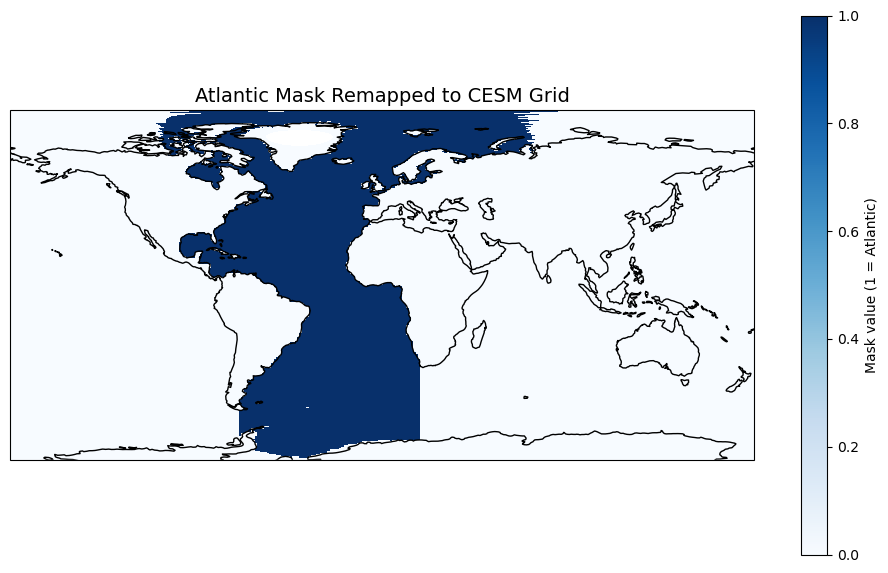

In [6]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# ---------------- Paths ----------------
mask_on_cesm_file = "/data/users/frekle/mask_bool_CESM.nc"

# ---------------- Load mask ----------------
ds_mask_cesm = xr.open_dataset(mask_on_cesm_file)
mask = ds_mask_cesm["atlmsk"]     # (nlat, nlon)
lat  = ds_mask_cesm["lat"]        # (nlat, nlon)
lon  = ds_mask_cesm["lon"]        # (nlat, nlon)

# ---------------- Plot ----------------
plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines for reference
ax.coastlines(resolution="110m", linewidth=1)

# Mask values are boolean-like (0/1). Show 1's as Atlantic ocean.
pc = plt.pcolormesh(
    lon,
    lat,
    mask,
    transform=ccrs.PlateCarree(),
    cmap="Blues",         # ocean mask = blue
    shading="nearest"
)

plt.title("Atlantic Mask Remapped to CESM Grid", fontsize=14)
plt.colorbar(pc, label="Mask value (1 = Atlantic)")

# Optional: focus on North Atlantic
# ax.set_extent([-100, 30, 0, 70], crs=ccrs.PlateCarree())

plt.show()


In [6]:
import xarray as xr
import numpy as np

paths = [
    "/data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thetao_masked_r13i1p1f1.nc",
    "/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao/thetao_masked_r5i1p1f1.nc",
    "/data/projects/nckf/frekle/CMIP6_data/CESM2/thetao/masked/thetao_masked_r2i1p1f1.nc",
]

for path in paths:
    print("\n==========================")
    print(f"FILE: {path}")
    ds = xr.open_dataset(path)

    var = "thetao"
    da = ds[var]

    print("Dims:", da.dims)

    # coordinate availability
    coords = list(ds.coords)
    print("Coordinate names:", coords)

    if "lat" in ds and "lon" in ds:
        lat = ds["lat"]
        lon = ds["lon"]
        print("lat shape:", lat.shape)
        print("lon shape:", lon.shape)

        if lat.ndim == 1 and lon.ndim == 1:
            print(">> Looks like REGULAR lat-lon grid.")
        elif lat.ndim == 2 and lon.ndim == 2:
            print(">> Looks like CURVILINEAR model ocean grid.")
        else:
            print(">> Lat/lon dimensionality unclear.")

        # Check spacing
        if lat.ndim == 1:
            print("First 10 lat deltas:", np.diff(lat.values[:10]))



FILE: /data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thetao_masked_r13i1p1f1.nc
Dims: ('time', 'lev', 'j', 'i')
Coordinate names: ['time', 'longitude', 'latitude', 'i', 'j', 'lev', 'y', 'x']

FILE: /data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao/thetao_masked_r5i1p1f1.nc
Dims: ('time', 'olevel', 'lat', 'lon')
Coordinate names: ['time', 'lon', 'lat', 'olevel']
lat shape: (180,)
lon shape: (360,)
>> Looks like REGULAR lat-lon grid.
First 10 lat deltas: [1. 1. 1. 1. 1. 1. 1. 1. 1.]

FILE: /data/projects/nckf/frekle/CMIP6_data/CESM2/thetao/masked/thetao_masked_r2i1p1f1.nc
Dims: ('time', 'lev', 'nlat', 'nlon')
Coordinate names: ['time', 'lon', 'lat', 'nlon', 'nlat', 'lev']
lat shape: (384, 320)
lon shape: (384, 320)
>> Looks like CURVILINEAR model ocean grid.


### Regrid and mask for EC-earth3 and CESM2

In [ ]:
#!/usr/bin/env python3
# =====================================================================
# UNIVERSAL REGRID + REMASK SCRIPT
#
# Loops over:
#   MODELS = ["EC-Earth3", "CESM2"]
#   members matching: r*i1p1f1
#   any VAR (thetao / so)
#
# Regrids each dataset (full depth) to IPSL 1x1 lat-lon grid,
# applies Atlantic mask,
# preserves full depth dimension,
# outputs as regridded masked NetCDFs.
# =====================================================================

import os
import glob
import numpy as np
import xarray as xr
import xesmf as xe

# =====================================================================
# CONFIG
# =====================================================================
# Change this between "thetao" and "so" as needed
VAR = "thetao"

MASK_PATH   = "/data/users/frekle/Masks/mask_bool_IPSL.nc"
NATIVE_ROOT = "/dmidata/projects/nckf/cmip6/historical"
OUT_ROOT    = "/data/projects/nckf/frekle/CMIP6_data"
WEIGHT_DIR  = "/data/projects/nckf/frekle/CMIP6_regrid_weights"

MODELS = ["EC-Earth3", "CESM2"]

# Search pattern for members, e.g. r1i1p1f1, r2i1p1f1, ...
MEMBER_PATTERN = "r*i1p1f1"
FILE_END       = "*.nc"

os.makedirs(WEIGHT_DIR, exist_ok=True)

# =====================================================================
# 1. Load target grid + Atlantic mask
# =====================================================================
print(f"\n📌 Loading target IPSL grid mask: {MASK_PATH}")
mask_ds = xr.open_dataset(MASK_PATH)

target_lat = mask_ds["lat"]           # (lat)
target_lon = mask_ds["lon"]           # (lon)
atl_mask   = mask_ds["atlmsk"] > 0    # boolean mask

target_grid = xr.Dataset(
    {"lat": target_lat, "lon": target_lon}
)

print(f"✔ Target grid: {target_lat.size} lat × {target_lon.size} lon\n")

# =====================================================================
# 2. Helper: Universal lat/lon finder
# =====================================================================
def find_lat_lon(ds):
    """Return lat, lon DataArrays regardless of naming."""
    lat = None
    lon = None

    for name in ["lat", "latitude", "nav_lat"]:
        if name in ds.coords:
            lat = ds[name]
            break

    for name in ["lon", "longitude", "nav_lon"]:
        if name in ds.coords:
            lon = ds[name]
            break

    if lat is None or lon is None:
        raise ValueError("Could not find latitude/longitude in dataset")

    return lat, lon

# =====================================================================
# 3. Helper: Standardize dims and build source grid for xESMF
# =====================================================================
def standardize_dims(ds, model_label):
    """
    Ensures ds uses dims ('y','x') and lat/lon match them.
    Works for:
       - EC-Earth3 tripolar curvilinear grids (j,i → y,x)
       - CESM2 POP2 curvilinear grids (nlat,nlon → y,x)
    """
    lat, lon = find_lat_lon(ds)

    rename_map = {}

    # EC-Earth3 / IPSL style curvilinear: dims (j, i)
    if lat.ndim == 2:
        ydim, xdim = lat.dims
        if ydim not in ["y"]:
            rename_map[ydim] = "y"
        if xdim not in ["x"]:
            rename_map[xdim] = "x"

    # CESM2 POP2: dims (nlat, nlon)
    if "nlat" in ds.dims:
        rename_map["nlat"] = "y"
    if "nlon" in ds.dims:
        rename_map["nlon"] = "x"

    if rename_map:
        print(f"[{model_label}] Renaming dims: {rename_map}")
        ds = ds.rename(rename_map)
        lat, lon = find_lat_lon(ds)  # refresh

    print(f"[{model_label}] lat dims: {lat.dims}, shape: {lat.shape}")
    print(f"[{model_label}] lon dims: {lon.dims}, shape: {lon.shape}")

    # Build mask of valid lon/lat cells
    valid = np.isfinite(lat) & np.isfinite(lon)
    mask = xr.DataArray(
        valid.astype(np.int32),
        dims=lat.dims,
        coords=lat.coords
    )

    src_grid = xr.Dataset(
        {"lat": lat, "lon": lon, "mask": mask}
    )

    return ds, src_grid

# =====================================================================
# 4. Regridder builder with weight caching
# =====================================================================
def build_regridder_with_cache(src_grid, model_label):
    """
    Build or reuse a regridder for a given model.
    Weights are cached to disk for speed.
    """
    weight_file = os.path.join(
        WEIGHT_DIR,
        f"{model_label}_to_IPSL_{VAR}_weights.nc"
    )

    if os.path.exists(weight_file):
        print(f"[{model_label}] 🔁 Reusing cached weights: {weight_file}")
        regridder = xe.Regridder(
            src_grid,
            target_grid,
            method="bilinear",
            periodic=True,
            ignore_degenerate=True,
            unmapped_to_nan=True,
            reuse_weights=True,
            filename=weight_file,
        )
    else:
        print(f"[{model_label}] 🧮 Computing weights for the first time...")
        regridder = xe.Regridder(
            src_grid,
            target_grid,
            method="bilinear",
            periodic=True,
            ignore_degenerate=True,
            unmapped_to_nan=True,
            reuse_weights=False,
            filename=weight_file,
        )
        print(f"[{model_label}] 💾 Saved weights to: {weight_file}")

    return regridder

# =====================================================================
# 5. Regrid + mask one member
# =====================================================================
def regrid_and_mask(ds_native, regridder, model_label, member_id):
    da = ds_native[VAR]

    print(f"  [{model_label} {member_id}] Regridding {VAR} ...")
    regridded = regridder(da)  # (time, lev, y, x) → (time, lev, lat, lon)

    # Attach target coords explicitly
    regridded = regridded.assign_coords(
        lat=target_lat,
        lon=target_lon
    )

    masked = regridded.where(atl_mask)

    masked.attrs["regridded_to_IPSL_mask"] = "Yes"
    masked.attrs["source_model"] = model_label
    masked.attrs["member"] = member_id
    masked.attrs["variable"] = VAR
    masked.attrs["grid"] = "IPSL 1x1 lat-lon (Atlantic masked)"

    return masked

# =====================================================================
# 6. MAIN LOOP OVER MODELS
# =====================================================================
for model in MODELS:

    print("\n" + "=" * 40)
    print(f"MODEL: {model} | VAR: {VAR}")
    print("=" * 40)

    model_base = os.path.join(NATIVE_ROOT, model)

    # find all matching member directories: r*i1p1f1
    member_dirs = sorted(
        glob.glob(os.path.join(model_base, MEMBER_PATTERN))
    )

    if not member_dirs:
        print(f"❌ No members found for {model} with pattern {MEMBER_PATTERN}")
        continue

    print(f"✔ Found {len(member_dirs)} members:")
    for md in member_dirs:
        print("   ", os.path.basename(md))
    print()

    # Output dir for this model + var
    out_dir = os.path.join(OUT_ROOT, model, VAR, "regridded")
    os.makedirs(out_dir, exist_ok=True)

    # -----------------------------------------------------------------
    # 6.1 Build regridder ONCE for this model (first member)
    # -----------------------------------------------------------------
    first_member_dir = member_dirs[0]
    first_member_id = os.path.basename(first_member_dir)
    native_dir_first = os.path.join(first_member_dir, "Oyear", VAR)
    nc_files_first = sorted(glob.glob(os.path.join(native_dir_first, FILE_END)))

    if not nc_files_first:
        print(f"⚠ No .nc files in {native_dir_first} for first member, skipping model {model}")
        continue

    print(f"[{model}] Using first member {first_member_id} to build regridder")
    print(f"[{model}] Files: {len(nc_files_first)}\n")

    ds_first = xr.open_mfdataset(
        nc_files_first,
        combine="by_coords",
        decode_times=True
    )

    ds_first, src_grid_first = standardize_dims(ds_first, model)
    regridder = build_regridder_with_cache(src_grid_first, model)

    ds_first.close()

    # -----------------------------------------------------------------
    # 6.2 Loop over all members for this model
    # -----------------------------------------------------------------
    for md in member_dirs:
        member_id = os.path.basename(md)
        native_dir = os.path.join(md, "Oyear", VAR)

        nc_files = sorted(glob.glob(os.path.join(native_dir, FILE_END)))
        if not nc_files:
            print(f"  ⚠ No .nc files in {native_dir}, skipping member {member_id}")
            continue

        out_file = os.path.join(
            out_dir,
            f"{VAR}_regridded_IPSLgrid_{model}_{member_id}.nc"
        )

        if os.path.exists(out_file):
            print(f"  [{model} {member_id}] ⏭ Output exists, skipping: {out_file}")
            continue

        print(f"\n▶ [{model}] Member: {member_id}")
        print(f"  Input dir: {native_dir}")
        print(f"  Files: {len(nc_files)}")

        ds_native = xr.open_mfdataset(
            nc_files,
            combine="by_coords",
            decode_times=True
        )

        # Make sure dims are standardized (y,x) so regridder matches
        ds_native, _ = standardize_dims(ds_native, model)

        masked = regrid_and_mask(ds_native, regridder, model, member_id)

        print(f"  Saving → {out_file}")
        masked.to_netcdf(out_file)

        ds_native.close()
        print(f"  ✅ Done for {model} {member_id}")

print("\n🎉 ALL MODELS + MEMBERS COMPLETE")
print(f"Regridding + Atlantic masking finished for VAR = {VAR}\n")



📌 Loading target IPSL grid mask: /data/users/frekle/Masks/mask_bool_IPSL.nc


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


✔ Target grid: 180 lat × 360 lon


MODEL: EC-Earth3 | VAR: thetao
✔ Found 25 members:
    r10i1p1f1
    r11i1p1f1
    r12i1p1f1
    r13i1p1f1
    r14i1p1f1
    r15i1p1f1
    r16i1p1f1
    r17i1p1f1
    r18i1p1f1
    r19i1p1f1
    r1i1p1f1
    r20i1p1f1
    r21i1p1f1
    r22i1p1f1
    r23i1p1f1
    r24i1p1f1
    r25i1p1f1
    r2i1p1f1
    r3i1p1f1
    r4i1p1f1
    r5i1p1f1
    r6i1p1f1
    r7i1p1f1
    r8i1p1f1
    r9i1p1f1

[EC-Earth3] Using first member r10i1p1f1 to build regridder
[EC-Earth3] Files: 1

[EC-Earth3] Renaming dims: {'j': 'y', 'i': 'x'}
[EC-Earth3] lat dims: ('y', 'x'), shape: (292, 362)
[EC-Earth3] lon dims: ('y', 'x'), shape: (292, 362)
[EC-Earth3] 🧮 Computing weights for the first time...
[EC-Earth3] 💾 Saved weights to: /data/projects/nckf/frekle/CMIP6_regrid_weights/EC-Earth3_to_IPSL_thetao_weights.nc

▶ [EC-Earth3] Member: r10i1p1f1
  Input dir: /dmidata/projects/nckf/cmip6/historical/EC-Earth3/r10i1p1f1/Oyear/thetao
  Files: 1
[EC-Earth3] Renaming dims: {'j': 'y', 

/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/core/computation.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 180.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (1, 362).
  result_var = func(*data_vars)
/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/dask/array/routines.py:333: PerformanceWarning: Increasing number of chunks by factor of 180
  intermediate = blockwise(


In [ ]:
#!/usr/bin/env python3
import xarray as xr
import numpy as np
from shapely.geometry import Point, MultiPoint
import os

# ================================================================
# CONFIG
# ================================================================
EC_MASK = "/data/users/mde/FREJA/subbasins.nc"
IPSL_NATIVE = "/data/projects/nckf/cmip6/historical/IPSL-CM6A-LR/r1i1p1f1/Oyear/so/so_Oyear_IPSL-CM6A-LR_historical_r1i1p1f1_gn_185001-201412.nc"

OUT_MASK = "/data/users/frekle/Masks/mask_bool_IPSL_native.nc"


# ================================================================
# 1. Load EC-Earth3 native grid mask
# ================================================================
print("Loading EC-Earth3 subbasins mask...")
ec = xr.open_dataset(EC_MASK)

atl = ec["atlmsk"]
ec_lat = ec["nav_lat"]
ec_lon = ec["nav_lon"]

print(f"EC mask dims: {atl.shape}  (expect 292 x 362)")


# Extract ocean points defining Atlantic
pts = [
    (float(ec_lon[j,i]), float(ec_lat[j,i]))
    for j in range(ec_lat.shape[0])
    for i in range(ec_lat.shape[1])
    if atl[j,i] > 0  # inside Atlantic
]

print(f"Extracted {len(pts)} EC-Earth3 Atlantic mask points.")

# Build polygon (convex hull)
poly = MultiPoint(pts).convex_hull
print("Convex hull polygon created.")
print("Bounds:", poly.bounds)


# ================================================================
# 2. Load IPSL native ocean grid
# ================================================================
print("\nLoading IPSL native grid...")
ipsl = xr.open_dataset(IPSL_NATIVE)

lat2 = ipsl["nav_lat"]  # (y,x)
lon2 = ipsl["nav_lon"]  # (y,x)

ny, nx = lat2.shape
print(f"IPSL native grid dims: {ny} x {nx}")


# ================================================================
# 3. Build IPSL native mask
# ================================================================
print("\nBuilding IPSL native Atlantic mask...")
atl_native = np.zeros((ny, nx), dtype=np.int8)

for j in range(ny):
    if j % 20 == 0:
        print(f" row {j}/{ny}...")

    for i in range(nx):
        pt = Point(float(lon2[j,i]), float(lat2[j,i]))
        if poly.contains(pt):
            atl_native[j,i] = 1


# ================================================================
# 4. Save output
# ================================================================
print("\nSaving IPSL native-grid mask...")
ds_out = xr.Dataset(
    {
        "atlmsk": (("y","x"), atl_native),
        "lat": (("y","x"), lat2.data),
        "lon": (("y","x"), lon2.data),
    },
    coords={
        "y": lat2.coords["y"],
        "x": lat2.coords["x"],
    }
)


ds_out.attrs["origin"] = "Projected from subbasins.nc onto IPSL native grid"
ds_out.attrs["comment"] = "True where IPSL grid cell center falls inside Atlantic region polygon"
ds_out.attrs["grid"] = "Native IPSL NEMO tripolar curvilinear (332 x 362)"

ds_out.to_netcdf(OUT_MASK)

print(f"\n🎉 Native-grid IPSL Atlantic mask saved:\n  {OUT_MASK}\n")


Loading EC-Earth3 subbasins mask...
EC mask dims: (292, 362)  (expect 292 x 362)
Extracted 18564 EC-Earth3 Atlantic mask points.
Convex hull polygon created.
Bounds: (-106.51609802246094, -78.14117431640625, 72.47296142578125, 89.74176788330078)

Loading IPSL native grid...
IPSL native grid dims: 332 x 362

Building IPSL native Atlantic mask...
 row 0/332...
 row 20/332...
 row 40/332...
 row 60/332...
 row 80/332...
 row 100/332...
 row 120/332...
 row 140/332...
 row 160/332...
 row 180/332...
 row 200/332...
 row 220/332...
 row 240/332...
 row 260/332...
 row 280/332...
 row 300/332...
 row 320/332...

Saving IPSL native-grid mask...

🎉 Native-grid IPSL Atlantic mask saved:
  /data/users/frekle/Masks/mask_bool_IPSL_native.nc



/tmp/ipykernel_2018832/4049346604.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(lon, lat, mask, cmap="Blues", shading="nearest")


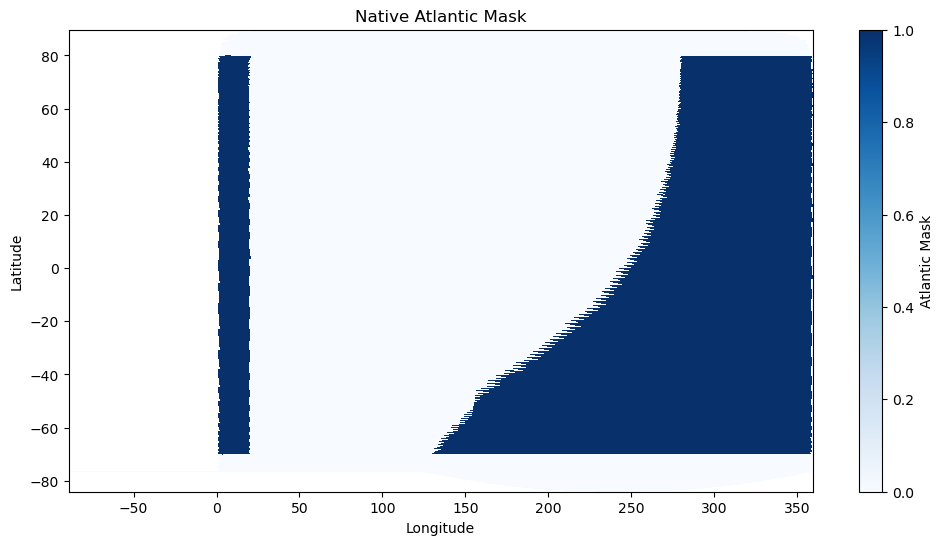

In [7]:
# Plot native mask for visual check without cartopy
import matplotlib.pyplot as plt

# import file paths
mask_file = "/data/users/frekle/Masks/mask_bool_MPI.nc"

ds_mask = xr.open_dataset(mask_file)
mask = ds_mask["atl_mask"]
lat = ds_mask["latitude"]
lon = ds_mask["longitude"]


plt.figure(figsize=(12,6))
plt.pcolormesh(lon, lat, mask, cmap="Blues", shading="nearest")
plt.colorbar(label="Atlantic Mask")
plt.title("Native Atlantic Mask")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
#!/usr/bin/env python3
# =====================================================================
# BUILD MPI ATLANTIC MASK USING ORIGINAL EC-Earth SUBBASIN MASK
#
# Steps:
# 1. Load subbasins.nc (ORCA grid)
# 2. Extract atlmsk + nav_lat + nav_lon
# 3. Load one MPI thetao file to get native lat/lon grid
# 4. Regrid ORCA mask → MPI grid (nearest neighbor)
# 5. Save final mask as boolean
# =====================================================================

import xarray as xr
import numpy as np
import xesmf as xe
import os

# ---------------------------------------------------------
# PATHS (UPDATE THESE)
# ---------------------------------------------------------
MODEL = "IPSL-CM6A-LR"

SUBBASINS = "/data/users/mde/FREJA/subbasins.nc"
MODEL_SAMPLE = f"/data/projects/nckf/cmip6/historical/{MODEL}/r1i1p1f1/Oyear/so/so_Oyear_{MODEL}_historical_r1i1p1f1_gn_185001-201412.nc"
OUT_MASK = f"/data/users/frekle/Masks/mask_bool_{MODEL}_native.nc"

print(f"\n=== BUILDING {MODEL} ATLANTIC MASK ===\n")

# ---------------------------------------------------------
# 1. Load subbasins
# ---------------------------------------------------------
ds_sub = xr.open_dataset(SUBBASINS)

if "atlmsk" not in ds_sub:
    raise KeyError("No 'atlmsk' in subbasins file!")

atl = ds_sub["atlmsk"]      # dims (y,x)
lat_orca = ds_sub["nav_lat"]
lon_orca = ds_sub["nav_lon"]

print("Loaded ORCA mask:")
print("  atlmsk:", atl.shape)
print("  nav_lat:", lat_orca.shape, "nav_lon:", lon_orca.shape)


# ---------------------------------------------------------
# Create ORCA source grid for regridding
# ---------------------------------------------------------
src_grid = xr.Dataset(
    {
        "lat": lat_orca,
        "lon": lon_orca
    }
)


# ---------------------------------------------------------
# 2. Load MPI native model to get target lat/lon
# ---------------------------------------------------------
print(f"\nLoading {MODEL} sample: {MODEL_SAMPLE}")
ds_model = xr.open_dataset(MODEL_SAMPLE)

# detect model coords
for cand in ["latitude", "nav_lat", "lat"]:
    if cand in ds_model:
        lat_model = ds_model[cand]
        break

for cand in ["longitude", "nav_lon", "lon"]:
    if cand in ds_model:
        lon_model = ds_model[cand]
        break

print("Model grid shapes:", lat_model.shape, lon_model.shape)

# wrap MPI lon to [-180,180]
lon_wrap = ((lon_model + 180) % 360) - 180

tgt_grid = xr.Dataset(
    {
        "lat": lat_model,
        "lon": lon_wrap
    }
)


# ---------------------------------------------------------
# 3. Build regridder (nearest neighbor)
# ---------------------------------------------------------
print("\n🔧 Regridding ORCA mask → model grid...")
rgr = xe.Regridder(
    src_grid,
    tgt_grid,
    method="nearest_s2d",
    periodic=True,
    ignore_degenerate=True,
    reuse_weights=False
)

# ---------------------------------------------------------
# 4. Apply regridding
# ---------------------------------------------------------
atl_interp = rgr(atl)

# enforce boolean
atl_bool = atl_interp > 0.5

print("Regridded mask dims:", atl_bool.shape)

# ---------------------------------------------------------
# 5. Save final mask
# ---------------------------------------------------------
out_ds = xr.Dataset(
    {
        "atlmsk": atl_bool.astype("int8"),
        "lat": lat_model,
        "lon": lon_wrap
    }
)

out_ds["atlmsk"].attrs["description"] = f"Atlantic mask remapped from ORCA subbasins to {MODEL} native grid"

out_ds.to_netcdf(OUT_MASK)

print(f"\n🎉 DONE! Saved native-grid MPI Atlantic mask → {OUT_MASK}\n")



=== BUILDING IPSL-CM6A-LR ATLANTIC MASK ===

Loaded ORCA mask:
  atlmsk: (292, 362)
  nav_lat: (292, 362) nav_lon: (292, 362)

Loading IPSL-CM6A-LR sample: /data/projects/nckf/cmip6/historical/IPSL-CM6A-LR/r1i1p1f1/Oyear/so/so_Oyear_IPSL-CM6A-LR_historical_r1i1p1f1_gn_185001-201412.nc
MPI grid shapes: (332, 362) (332, 362)

🔧 Regridding ORCA mask → MPI grid...
Regridded mask dims: (332, 362)

🎉 DONE! Saved native-grid MPI Atlantic mask → /data/users/frekle/Masks/mask_bool_IPSL-CM6A-LR_native.nc



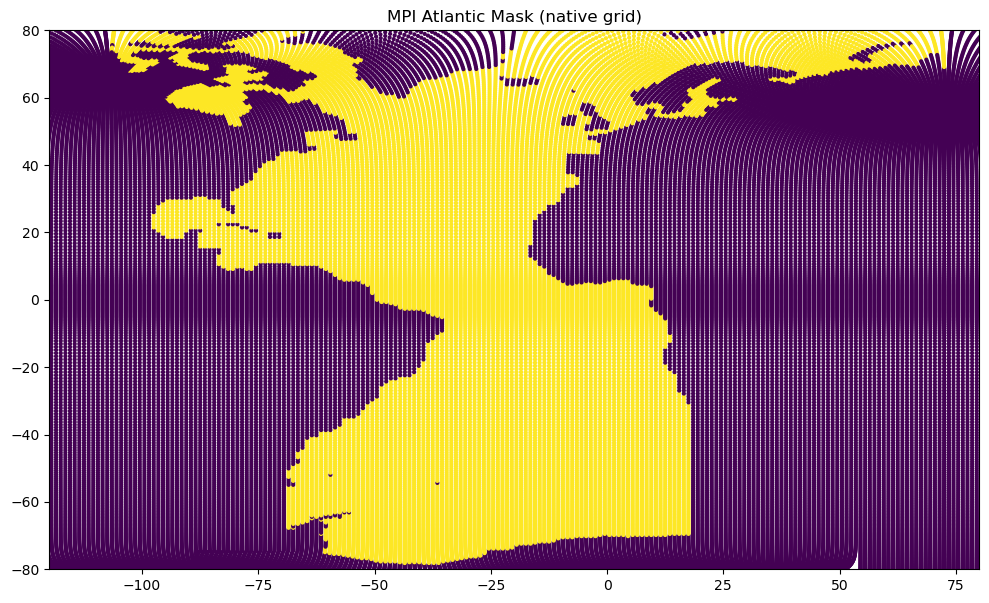

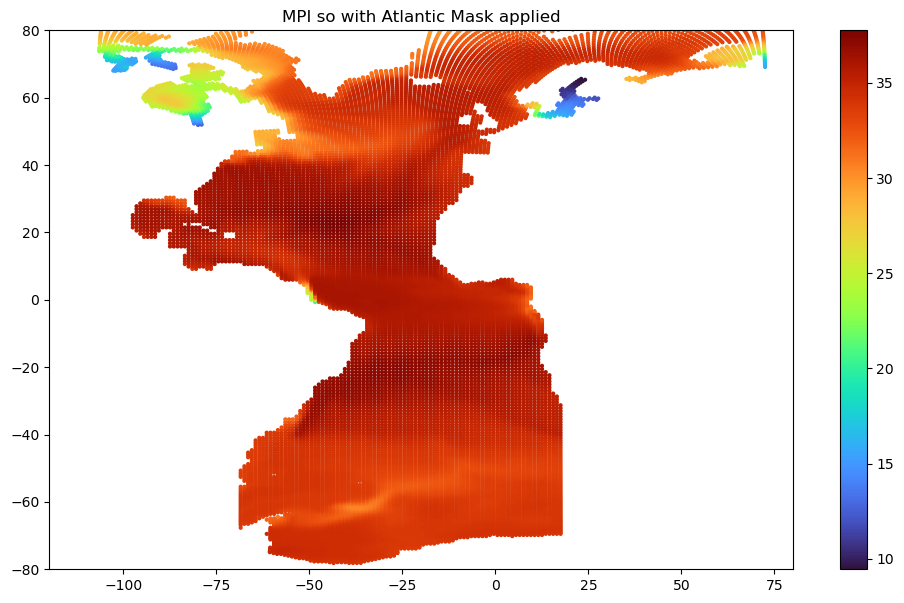

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

mask = xr.open_dataset(f"/data/users/frekle/Masks/mask_bool_{MODEL}_native.nc")
ds = xr.open_dataset(MODEL_SAMPLE)

VAR = "so"

var_data = ds[f"{VAR}"].isel(time=0, olevel=0)
usemask = mask["atlmsk"] > 0

plt.figure(figsize=(12,7))
plt.scatter(mask["lon"], mask["lat"], s=4, c=usemask, cmap="viridis")
plt.title("MPI Atlantic Mask (native grid)")
plt.xlim(-120,80)
plt.ylim(-80,80)
plt.show()

plt.figure(figsize=(12,7))
plt.scatter(mask["lon"], mask["lat"], s=4, c=var_data.where(usemask), cmap="turbo")
plt.title(f"{MODEL} {VAR} with Atlantic Mask applied")
plt.xlim(-120,80)
plt.ylim(-80,80)
plt.colorbar()
plt.show()


#### Build masked files

In [17]:
#!/usr/bin/env python3
# =================================================================
# UNIVERSAL CMIP6 MASKING SCRIPT (MPI, IPSL, CESM, EC-Earth, ...)
#
# - Handles ANY native grid (curvilinear or lat/lon)
# - Auto-detects horizontal dimensions
# - Auto-detects lat/lon variable names
# - Applies a supplied mask file (same grid)
# - Saves masked files to unified directory
# =================================================================

import os
import xarray as xr
import numpy as np

# ---------------------------------------------------------
# USER SETTINGS — YOU FILL THESE IN
# ---------------------------------------------------------
MODEL = "IPSL-CM6A-LR"         # e.g. MPI-ESM1-2-LR, IPSL-CM6A-LR, CESM2, EC-Earth3
VAR   = "thetao"                # ocean variable: thetao, so, vo, etc.

NATIVE_ROOT = f"/data/projects/nckf/cmip6/historical/{MODEL}"         # YOU SET THIS
MASK_PATH   = f"/data/users/frekle/Masks/mask_bool_{MODEL}_native.nc"          # YOU SET THIS

MASKED_DIR  = f"/data/projects/nckf/frekle/CMIP6_data/{MODEL}/{VAR}/masked/"
os.makedirs(MASKED_DIR, exist_ok=True)

print(f"\n=== Masking native-grid {MODEL} — variable {VAR} ===")
print(f"Mask file: {MASK_PATH}\n")


# =========================================================
# Helper: detect 2D spatial dims (j/i vs y/x vs lat/lon)
# =========================================================
def get_horizontal_dims(da):
    """Return names of horizontal dims (ny, nx)."""
    candidates_2d = [
        ("j", "i"),
        ("y", "x"),
        ("nj", "ni"),
        ("nlat", "nlon"),
        ("lat", "lon"),
    ]
    for ydim, xdim in candidates_2d:
        if ydim in da.dims and xdim in da.dims:
            return ydim, xdim
    raise ValueError(f"Could not identify horizontal dims in {da.dims}")


# =========================================================
# Helper: detect lat/lon variable names
# =========================================================
def find_lat_lon(ds):
    """Return lat, lon DataArrays from dataset."""
    LAT_NAMES = ["lat", "latitude", "nav_lat", "geolat"]
    LON_NAMES = ["lon", "longitude", "nav_lon", "geolon"]

    lat = None
    lon = None

    for ln in LAT_NAMES:
        if ln in ds:
            lat = ds[ln]
            break
    for ln in LON_NAMES:
        if ln in ds:
            lon = ds[ln]
            break

    if lat is None or lon is None:
        raise KeyError("Could not find lat/lon in dataset.")

    return lat, lon


# =========================================================
# 1. Load MASK
# =========================================================
mask_ds = xr.open_dataset(MASK_PATH)

# Try to detect mask variable
MASK_VAR_CANDIDATES = ["atlmsk", "mask", "atl_mask", "mask_bool"]
mask_var = None
for m in MASK_VAR_CANDIDATES:
    if m in mask_ds:
        mask_var = m
        break

if mask_var is None:
    raise KeyError(
        f"No mask variable found in {MASK_PATH}. "
        f"Looked for: {MASK_VAR_CANDIDATES}"
    )

mask = mask_ds[mask_var] > 0

# Horizontal dims of mask
my, mx = mask.shape[-2], mask.shape[-1]
mask_dims = mask.dims[-2:]

print(f"Loaded mask '{mask_var}' with dims {mask_dims}: {mask.shape}")


# =========================================================
# 2. Collect native model files (IPSL, CESM, MPI, etc.)
# =========================================================

native_files = []

for member in sorted(os.listdir(NATIVE_ROOT)):
    # Find folders like r1i1p1f1, r2i1p1f1, ...
    if member.startswith("r") and "i1p1f1" in member:
        var_dir = os.path.join(NATIVE_ROOT, member, "Oyear", VAR)

        if os.path.isdir(var_dir):
            # Example IPSL filename:
            # thetao_Oyear_IPSL-CM6A-LR_historical_r1i1p1f1_gn_185001-201412.nc
            pattern = f"{VAR}_Oyear_{MODEL}_historical_{member}_*.nc"

            for fn in sorted(os.listdir(var_dir)):
                if fn.startswith(f"{VAR}_Oyear") and fn.endswith(".nc"):
                    native_files.append(os.path.join(var_dir, fn))

if not native_files:
    raise FileNotFoundError(
        f"No native {VAR} files found under {NATIVE_ROOT}"
    )

print(f"Found {len(native_files)} files:")
for f in native_files:
    print("  " + os.path.basename(f))
print()



# =========================================================
# 3. Mask each file
# =========================================================
for path in native_files:
    fname = os.path.basename(path)
    print(f"\n→ Processing: {fname}")

    ds = xr.open_dataset(path)

    if VAR not in ds:
        raise KeyError(f"Variable '{VAR}' not found in {fname}")

    da = ds[VAR]

    # Detect horizontal dims in data
    ydim, xdim = get_horizontal_dims(da)
    print(f"Detected spatial dims: {ydim}, {xdim}")

    # Ensure grids match
    if da.sizes[ydim] != my or da.sizes[xdim] != mx:
        raise ValueError(
            f"Grid mismatch for {fname}:\n"
            f"  Data dims: ({ydim}={da.sizes[ydim]}, {xdim}={da.sizes[xdim]})\n"
            f"  Mask dims: ({my}, {mx})"
        )

    # Apply mask
    masked = da.where(mask)

    # Attach lat/lon if needed
    try:
        lat, lon = find_lat_lon(ds)
        masked = masked.assign_coords(lat=lat, lon=lon)
    except Exception:
        print("  WARNING: lat/lon not found in data — skipping coordinate attachment")

    # Output filename
    outname = fname.replace(".nc", "_masked.nc")
    outpath = os.path.join(MASKED_DIR, outname)

    print(f"  Saving → {outpath}")
    masked.to_netcdf(outpath)

print("\n🎉 Masking completed for all models!")
print(f"Results saved in:\n   {MASKED_DIR}\n")



=== Masking native-grid IPSL-CM6A-LR — variable thetao ===
Mask file: /data/users/frekle/Masks/mask_bool_IPSL-CM6A-LR_native.nc

Loaded mask 'atlmsk' with dims ('y', 'x'): (332, 362)
Found 33 files:
  thetao_Oyear_IPSL-CM6A-LR_historical_r10i1p1f1_gn_185001-201412.nc
  thetao_Oyear_IPSL-CM6A-LR_historical_r11i1p1f1_gn_185001-201412.nc
  thetao_Oyear_IPSL-CM6A-LR_historical_r12i1p1f1_gn_185001-201412.nc
  thetao_Oyear_IPSL-CM6A-LR_historical_r13i1p1f1_gn_185001-201412.nc
  thetao_Oyear_IPSL-CM6A-LR_historical_r14i1p1f1_gn_185001-201412.nc
  thetao_Oyear_IPSL-CM6A-LR_historical_r15i1p1f1_gn_185001-201412.nc
  thetao_Oyear_IPSL-CM6A-LR_historical_r16i1p1f1_gn_185001-201412.nc
  thetao_Oyear_IPSL-CM6A-LR_historical_r17i1p1f1_gn_185001-201412.nc
  thetao_Oyear_IPSL-CM6A-LR_historical_r18i1p1f1_gn_185001-201412.nc
  thetao_Oyear_IPSL-CM6A-LR_historical_r19i1p1f1_gn_185001-201412.nc
  thetao_Oyear_IPSL-CM6A-LR_historical_r1i1p1f1_gn_185001-201412.nc
  thetao_Oyear_IPSL-CM6A-LR_historical_r20

/tmp/ipykernel_1637926/3921732699.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(lon, lat, data, shading="nearest", cmap="turbo")


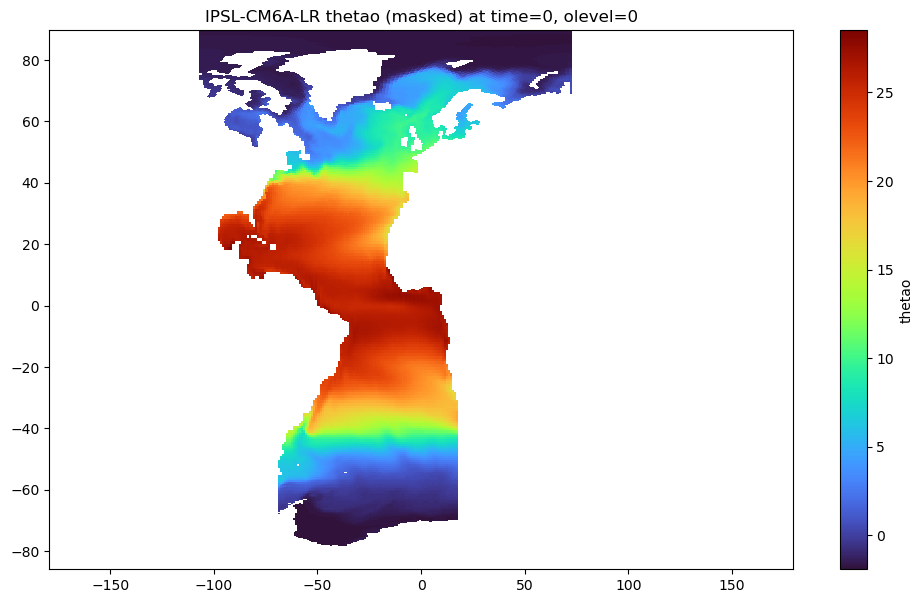

In [4]:
# plot one time slice of masked data for IPSL
import xarray as xr
import matplotlib.pyplot as plt
model = "IPSL-CM6A-LR"
var = "thetao"
file = f"/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR//thetao/masked/thetao_Oyear_IPSL-CM6A-LR_historical_r10i1p1f1_gn_185001-201412_masked.nc"

ds = xr.open_dataset(file)
data = ds[var].isel(time=0, olevel=0)
lat = ds["lat"]
lon = ds["lon"]
plt.figure(figsize=(12,7))
plt.pcolormesh(lon, lat, data, shading="nearest", cmap="turbo")
plt.colorbar(label=var)
plt.title(f"{model} {var} (masked) at time=0, olevel=0")
plt.show()
